
# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 0 — AI-Assisted Synthetic Dataset Generation and Validation

This notebook creates a fully synthetic questionnaire dataset that matches the attached questionnaire export in:

- the same **25 columns**;
- the same column order;
- the same categorical wording;
- the same data types and date format;
- the same optional open-ended fields.

The generated dataset contains **2,500 records**. Academic outcomes are generated through probabilistic, non-deterministic relationships aligned with the study hypotheses. The resulting data can be loaded by Phase 1 exactly like an independent questionnaire export.

> **Research-use statement:** The generated records do not represent real students, families, schools, or official Ministry of Education data. Synthetic-data results test the proposed methodology and must not be reported as empirical evidence about Bahrain.



## Output Folder Structure

```text
outputs/
└── Phase_00_AI_Assisted_Synthetic_Dataset_Generation_and_Validation/
    └── Section_00_XX_Section_Title/
        └── Cell_00_XX_XX_Cell_Title/
            ├── tables/
            ├── figures/
            ├── reports/
            └── files/
```

The final handoff package contains the synthetic CSV/XLSX dataset, schema report, validation reports, manifest, and ZIP archive for use by Phase 1.



# Section 0.1 — Project Information and Execution Environment

**Description:** Defines the project identity, selects the execution environment through one variable, and creates the Phase → Section → Cell output structure.


In [1]:

# Cell 0.1.1 — Select Execution Environment and Create Project Folders

from pathlib import Path
from datetime import datetime
import json
import os
import re
import sys

# ================================================================
# CHANGE THIS VARIABLE ONLY
# Allowed values: "COLAB", "ANACONDA", "VSCODE"
# ================================================================
EXECUTION_ENVIRONMENT = "VSCODE"

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

allowed_environments = {"COLAB", "ANACONDA", "VSCODE"}
EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()

if EXECUTION_ENVIRONMENT not in allowed_environments:
    raise ValueError(
        f"EXECUTION_ENVIRONMENT must be one of {sorted(allowed_environments)}"
    )

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_ROOT = Path("/content/drive/MyDrive/Jaafar_MSc_Thesis")
    except ImportError:
        print("Colab is not available; a local fallback folder will be used.")
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_SOURCE_DIR = PROJECT_ROOT / "data_source"
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
PHASE_DIR = (
    OUTPUT_ROOT
    / "Phase_00_AI_Assisted_Synthetic_Dataset_Generation_and_Validation"
)

DATA_SOURCE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
PHASE_DIR.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

def safe_name(text):
    """Convert a title to a safe and readable folder/file name."""
    text = str(text).strip().replace("—", "-").replace("–", "-")
    text = re.sub(r"[^\w\-]+", "_", text, flags=re.UNICODE)
    return re.sub(r"_+", "_", text).strip("_") or "Unnamed"

def create_cell_folders(section_number, section_title, cell_number, cell_title):
    """Create the approved Phase → Section → Cell folder hierarchy."""
    section_folder = PHASE_DIR / safe_name(
        f"Section_{section_number}_{section_title}"
    )
    cell_folder = section_folder / safe_name(
        f"Cell_{cell_number}_{cell_title}"
    )

    folders = {
        "cell": cell_folder,
        "tables": cell_folder / "tables",
        "figures": cell_folder / "figures",
        "reports": cell_folder / "reports",
        "files": cell_folder / "files",
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders

CELL_FOLDERS = create_cell_folders(
    "00_01",
    "Project_Information_and_Execution_Environment",
    "00_01_01",
    "Select_Execution_Environment_and_Create_Project_Folders",
)

project_configuration = {
    "project_title": PROJECT_TITLE,
    "programme": PROGRAMME,
    "student_name": STUDENT_NAME,
    "student_id": STUDENT_ID,
    "execution_environment": EXECUTION_ENVIRONMENT,
    "project_root": str(PROJECT_ROOT),
    "data_source_directory": str(DATA_SOURCE_DIR),
    "data_directory": str(DATA_DIR),
    "phase_directory": str(PHASE_DIR),
    "run_timestamp": RUN_TIMESTAMP,
}

with (
    CELL_FOLDERS["reports"] / "00_01_01_project_configuration.json"
).open("w", encoding="utf-8") as file:
    json.dump(project_configuration, file, ensure_ascii=False, indent=2)

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Project root:", PROJECT_ROOT)
print("Optional source folder:", DATA_SOURCE_DIR)
print("Study dataset folder:", DATA_DIR)
print("Phase folder:", PHASE_DIR)


Execution environment: VSCODE
Project root: C:\Users\User\Desktop\All
Optional source folder: C:\Users\User\Desktop\All\data_source
Study dataset folder: C:\Users\User\Desktop\All\data
Phase folder: C:\Users\User\Desktop\All\outputs\Phase_00_AI_Assisted_Synthetic_Dataset_Generation_and_Validation



# Section 0.2 — Install Required Libraries

**Description:** Checks the Python libraries required by Phase 0 and installs only packages that are missing.


In [2]:

# Cell 0.2.1 — Check and Install Missing Libraries

import importlib.util
import subprocess

CELL_FOLDERS = create_cell_folders(
    "00_02",
    "Install_Required_Libraries",
    "00_02_01",
    "Check_and_Install_Missing_Libraries",
)

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "openpyxl": "openpyxl",
}

installation_report = []

for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None

    if installed:
        status = "Already installed"
    else:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package_name]
        )
        status = "Installed during this run"

    installation_report.append(
        {
            "import_name": import_name,
            "package_name": package_name,
            "status": status,
        }
    )

print("Library check completed.")
for item in installation_report:
    print(f"- {item['package_name']}: {item['status']}")


Library check completed.
- pandas: Already installed
- numpy: Already installed
- matplotlib: Already installed
- scipy: Already installed
- openpyxl: Already installed



# Section 0.3 — Import Libraries, Visual Theme, and Export Functions

**Description:** Imports the libraries, fixes reproducibility settings, defines a distinctive project visual identity, and creates reusable export functions.


In [3]:

# Cell 0.3.1 — Import Libraries and Define the Project Visual Theme

import json
import math
import random
import shutil
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.stats import chi2_contingency, gaussian_kde

warnings.filterwarnings("default")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
RNG = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

# Distinctive Bahrain Thesis visual identity.
THEME = {
    "maroon": "#6B1E32",
    "gold": "#D4A64A",
    "teal": "#237A7A",
    "coral": "#D96850",
    "indigo": "#525B92",
    "sage": "#6D8B74",
    "warm_white": "#F7F4EF",
    "charcoal": "#2E3035",
    "light_gray": "#E8E4DE",
}

CLASS_COLORS = {
    "Low": THEME["coral"],
    "Medium": THEME["gold"],
    "High": THEME["teal"],
}

plt.rcParams.update(
    {
        "figure.facecolor": THEME["warm_white"],
        "axes.facecolor": THEME["warm_white"],
        "axes.edgecolor": THEME["charcoal"],
        "axes.labelcolor": THEME["charcoal"],
        "text.color": THEME["charcoal"],
        "xtick.color": THEME["charcoal"],
        "ytick.color": THEME["charcoal"],
        "font.size": 11,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    }
)

CELL_FOLDERS = create_cell_folders(
    "00_03",
    "Import_Libraries_Visual_Theme_and_Export_Functions",
    "00_03_01",
    "Import_Libraries_and_Define_the_Project_Visual_Theme",
)

library_versions = pd.DataFrame(
    {
        "library": ["Python", "pandas", "numpy", "matplotlib"],
        "version": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            plt.matplotlib.__version__,
        ],
    }
)

library_versions.to_csv(
    CELL_FOLDERS["tables"] / "00_03_01_library_versions.csv",
    index=False,
    encoding="utf-8-sig",
)
display(library_versions)


,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,matplotlib,3.10.0


In [4]:

# Cell 0.3.2 — Define Reusable Export and Plot Functions

def save_dataframe(dataframe, folders, file_stem, index=False):
    """Save a table in CSV and Excel formats."""
    csv_path = folders["tables"] / f"{file_stem}.csv"
    xlsx_path = folders["tables"] / f"{file_stem}.xlsx"

    dataframe.to_csv(csv_path, index=index, encoding="utf-8-sig")
    dataframe.to_excel(xlsx_path, index=index)
    return {"csv": csv_path, "xlsx": xlsx_path}


def save_json_report(data, folders, file_stem):
    """Save a dictionary or list as a formatted JSON report."""
    path = folders["reports"] / f"{file_stem}.json"
    with path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def save_figure(figure, folders, file_stem):
    """Save a figure as a high-resolution PNG."""
    path = folders["figures"] / f"{file_stem}.png"
    figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor=figure.get_facecolor(),
    )
    return path


def add_figure_footer(figure, text="Synthetic questionnaire data — Phase 0"):
    """Add a consistent footer to each project figure."""
    figure.text(
        0.01,
        0.01,
        text,
        ha="left",
        va="bottom",
        fontsize=8,
        color="#666666",
    )


def style_axis(axis, grid_axis="y"):
    """Apply the project chart style without using a default template."""
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_alpha(0.35)
    axis.spines["bottom"].set_alpha(0.35)
    axis.grid(axis=grid_axis, alpha=0.18, linestyle="--")
    axis.set_axisbelow(True)


def cramers_v(series_a, series_b):
    """Calculate Chi-square p-value and bias-corrected Cramér's V."""
    table = pd.crosstab(series_a, series_b)
    chi2, p_value, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    rows, columns = table.shape

    phi2 = chi2 / n
    phi2_corrected = max(
        0,
        phi2 - ((columns - 1) * (rows - 1)) / (n - 1),
    )
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)

    effect_size = (
        math.sqrt(phi2_corrected / denominator)
        if denominator > 0
        else 0.0
    )
    return float(chi2), float(p_value), float(effect_size)


def academic_class(average):
    """Create the approved Low/Medium/High label from semester one."""
    if average < 75:
        return "Low"
    if average < 90:
        return "Medium"
    return "High"


CELL_FOLDERS = create_cell_folders(
    "00_03",
    "Import_Libraries_Visual_Theme_and_Export_Functions",
    "00_03_02",
    "Define_Reusable_Export_and_Plot_Functions",
)

function_catalogue = pd.DataFrame(
    {
        "function": [
            "save_dataframe",
            "save_json_report",
            "save_figure",
            "add_figure_footer",
            "style_axis",
            "cramers_v",
            "academic_class",
        ],
        "purpose": [
            "Export tables as CSV and XLSX",
            "Export structured JSON reports",
            "Export high-resolution figures",
            "Apply a consistent project footer",
            "Apply the custom chart appearance",
            "Measure categorical association",
            "Create Low, Medium, and High labels",
        ],
    }
)

save_dataframe(
    function_catalogue,
    CELL_FOLDERS,
    "00_03_02_function_catalogue",
)
display(function_catalogue)


,function,purpose
0,save_dataframe,Export tables as CSV and XLSX
1,save_json_report,Export structured JSON reports
2,save_figure,Export high-resolution figures
3,add_figure_footer,Apply a consistent project footer
4,style_axis,Apply the custom chart appearance
5,cramers_v,Measure categorical association
6,academic_class,"Create Low, Medium, and High labels"


# Section 0.4 — Optional Source Dataset and Synthetic-Data Governance

**Description:** Searches the dedicated `data_source` folder for an optional questionnaire reference file. Any supported filename is accepted and standardised internally as `source.csv`. If no source file is available, generation continues directly using the approved built-in schema, categories, constraints, and hypothesis-aligned rules.

In [5]:
# Cell 0.4.1 — Locate an Optional Source File or Use Built-in Rules

CELL_FOLDERS = create_cell_folders(
    "00_04",
    "Optional_Source_Dataset_and_Synthetic_Data_Governance",
    "00_04_01",
    "Locate_Optional_Source_File_or_Use_Built_in_Rules",
)

# The final synthetic dataset must always follow this exact schema.
EXPECTED_COLUMNS = [
    "Family ID",
    "Father Alive",
    "Mother Alive",
    "Father's Education",
    "Mother's Education",
    "Father's Job",
    "Mother's Job",
    "Marital Status",
    "Family Income",
    "Number of Family Members",
    "Gender",
    "School Type",
    "Stage",
    "Grade",
    "Tutoring Support",
    "Social Activities",
    "Chronic Disease",
    "First Semester Average",
    "Second Semester Average",
    "Difference (Semester 2 - Semester 1)",
    "Daily Smart Device Usage",
    "Other Influencing Factors",
    "Additional Suggestions",
    "Response Language",
    "Submission Date",
]

# Approved categories used when no source file is supplied.
APPROVED_CATEGORIES = {
    "Father Alive": ["Yes", "No"],
    "Mother Alive": ["Yes", "No"],
    "Father's Education": [
        "Primary", "Intermediate", "Secondary", "Diploma",
        "Bachelor's", "Master's", "PhD",
    ],
    "Mother's Education": [
        "Primary", "Secondary", "Diploma", "Bachelor's", "Master's",
    ],
    "Father's Job": [
        "Employed", "Unemployed", "Retired", "Self-employed",
    ],
    "Mother's Job": [
        "Employed", "Unemployed", "Retired", "Self-employed",
    ],
    "Marital Status": ["Married", "Separated", "Widow", "Widower"],
    "Family Income": [
        "Less than 300 BHD",
        "300 – 700 BHD",
        "700 – 1000 BHD",
        "More than 1000 BHD",
    ],
    "Gender": ["Male", "Female"],
    "School Type": ["Government", "Private"],
    "Stage": ["Primary", "Intermediate", "Secondary"],
    "Grade": ["First", "Second", "Third", "Fourth", "Fifth", "Sixth"],
    "Tutoring Support": ["Yes", "No"],
    "Social Activities": ["Yes", "No"],
    "Chronic Disease": ["Yes", "No"],
    "Daily Smart Device Usage": [
        "Less than an hour",
        "1 - 3 hours",
        "3 - 5 hours",
        "More than 5 hours",
    ],
    "Response Language": ["Arabic"],
}

SUPPORTED_SOURCE_TYPES = {".csv", ".xlsx", ".xls"}
STANDARD_SOURCE_PATH = DATA_SOURCE_DIR / "source.csv"


def load_source_file(path):
    """Load a supported optional source file without modifying its values."""
    if path.suffix.lower() == ".csv":
        try:
            return pd.read_csv(path, encoding="utf-8-sig")
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="latin-1")

    return pd.read_excel(path)


def select_optional_source_file():
    """
    Select a reference file only from data_source.

    Priority:
    1. data_source/source.csv
    2. The only supported file in data_source
    3. The most recently modified supported file when several exist
    4. None when the folder is empty
    """
    if STANDARD_SOURCE_PATH.exists():
        return STANDARD_SOURCE_PATH, "Preferred official source.csv"

    candidates = sorted(
        [
            path
            for path in DATA_SOURCE_DIR.iterdir()
            if path.is_file()
            and path.suffix.lower() in SUPPORTED_SOURCE_TYPES
        ],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    if not candidates:
        return None, "No source file supplied; built-in rules will be used"

    if len(candidates) == 1:
        return candidates[0], "Single supported source file found"

    print(
        "Several files were found in data_source. "
        "The most recently modified file will be used:"
    )
    for candidate in candidates:
        print("-", candidate.name)

    return candidates[0], "Most recently modified supported source selected"


ORIGINAL_SOURCE_PATH, SOURCE_SELECTION_REASON = (
    select_optional_source_file()
)

if ORIGINAL_SOURCE_PATH is None:
    SOURCE_AVAILABLE = False
    REFERENCE_DATA_PATH = None
    reference_data = pd.DataFrame(columns=EXPECTED_COLUMNS)
    SOURCE_MODE = "BUILT_IN_RULES"

    print(
        "No file was found in data_source.\n"
        "Synthetic generation will continue directly using the approved "
        "25-column schema, categories, distributions, constraints, and "
        "hypothesis-aligned rules."
    )
else:
    SOURCE_AVAILABLE = True
    SOURCE_MODE = "REFERENCE_FILE"
    loaded_source_data = load_source_file(ORIGINAL_SOURCE_PATH)

    if loaded_source_data.empty:
        raise ValueError(
            f"The selected source file is empty: {ORIGINAL_SOURCE_PATH}"
        )

    if loaded_source_data.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(
            "The selected source file does not match the approved "
            "25-column questionnaire schema.\n"
            f"Selected file: {ORIGINAL_SOURCE_PATH}\n"
            f"Observed columns: {loaded_source_data.columns.tolist()}"
        )

    # Use the source only for schema/category/distribution guidance.
    reference_data = loaded_source_data.copy()

    # Standardise the optional reference name for all future runs.
    reference_data.to_csv(
        STANDARD_SOURCE_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    REFERENCE_DATA_PATH = STANDARD_SOURCE_PATH

    print("Optional source file loaded:", ORIGINAL_SOURCE_PATH.name)
    print("Official standardised source:", STANDARD_SOURCE_PATH)
    print("Reference shape:", reference_data.shape)
    display(reference_data.head(3))

reference_summary = {
    "source_available": SOURCE_AVAILABLE,
    "source_mode": SOURCE_MODE,
    "selection_reason": SOURCE_SELECTION_REASON,
    "data_source_directory": str(DATA_SOURCE_DIR),
    "original_source_file": (
        str(ORIGINAL_SOURCE_PATH)
        if ORIGINAL_SOURCE_PATH is not None
        else None
    ),
    "official_source_file": (
        str(REFERENCE_DATA_PATH)
        if REFERENCE_DATA_PATH is not None
        else None
    ),
    "reference_rows": (
        int(reference_data.shape[0]) if SOURCE_AVAILABLE else 0
    ),
    "reference_columns": len(EXPECTED_COLUMNS),
    "generation_continues_without_source": True,
    "purpose": (
        "An optional source is used only as a schema, category, "
        "formatting, and distribution reference. No real row is copied "
        "into the final synthetic dataset."
    ),
}

save_json_report(
    reference_summary,
    CELL_FOLDERS,
    "00_04_01_optional_source_summary",
)

source_status_table = pd.DataFrame(
    [
        ["Source available", SOURCE_AVAILABLE],
        ["Generation mode", SOURCE_MODE],
        ["Source folder", str(DATA_SOURCE_DIR)],
        [
            "Official source name",
            "source.csv" if SOURCE_AVAILABLE else "Not applicable",
        ],
        ["Generation can continue", True],
    ],
    columns=["item", "value"],
)

save_dataframe(
    source_status_table,
    CELL_FOLDERS,
    "00_04_01_source_status",
)
display(source_status_table)

Optional source file loaded: questionnaire_results_en_2026-07-19_01-56-43.csv
Official standardised source: C:\Users\User\Desktop\All\data_source\source.csv
Reference shape: (385, 25)


,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date
0,1,Yes,Yes,Master's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Fourth,No,Yes,Yes,100.0,100.0,0.0,1 - 3 hours,تشجيع الوالدين والمعلمين,NaN,Arabic,2026-07-09 11:41:54
1,2,Yes,Yes,Master's,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,2,Female,Government,Primary,Fourth,Yes,Yes,No,99.0,100.0,1.0,Less than an hour,NaN,NaN,Arabic,2026-07-09 13:47:39
2,3,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,700 – 1000 BHD,2,Male,Government,Primary,First,Yes,Yes,No,90.0,92.0,2.0,Less than an hour,لا,NaN,Arabic,2026-07-10 16:43:18


,item,value
0,Source available,True
1,Generation mode,REFERENCE_FILE
2,Source folder,C:\Users\User\Desktop\All\data_source
3,Official source name,source.csv
4,Generation can continue,True


In [6]:

# Cell 0.4.2 — Document Synthetic-Data Governance and Research Use

CELL_FOLDERS = create_cell_folders(
    "00_04",
    "Reference_Dataset_and_Synthetic_Data_Governance",
    "00_04_02",
    "Document_Synthetic_Data_Governance_and_Research_Use",
)

governance_statement = {
    "data_status": "Fully synthetic",
    "contains_real_students": False,
    "contains_personal_identifiers": False,
    "permitted_uses": [
        "Testing the preprocessing pipeline",
        "Testing machine-learning algorithms",
        "Evaluating code reproducibility",
        "Demonstrating the proposed methodology",
        "Running simulation-based sensitivity analyses",
    ],
    "prohibited_claims": [
        "The data prove the hypotheses in the Bahraini population",
        "The records represent actual students or families",
        "The results are official Ministry of Education findings",
    ],
    "plans": {
        "Plan A": "Primary data collected through the questionnaire",
        "Plan B": "Official educational data from the Ministry of Education",
        "Plan C": "AI-assisted synthetic data for methodological testing",
    },
}

save_json_report(
    governance_statement,
    CELL_FOLDERS,
    "00_04_02_synthetic_data_governance",
)

governance_table = pd.DataFrame(
    [
        ["Plan A", governance_statement["plans"]["Plan A"]],
        ["Plan B", governance_statement["plans"]["Plan B"]],
        ["Plan C", governance_statement["plans"]["Plan C"]],
    ],
    columns=["Data plan", "Description"],
)
save_dataframe(
    governance_table,
    CELL_FOLDERS,
    "00_04_02_data_plan_documentation",
)
display(governance_table)


,Data plan,Description
0,Plan A,Primary data collected through the questionnaire
1,Plan B,Official educational data from the Ministry of...
2,Plan C,AI-assisted synthetic data for methodological ...



# Section 0.5 — Exact Schema and Data Dictionary

**Description:** Extracts the exact 25-column schema from the reference file and creates the Phase 0 data dictionary without adding any column to the final synthetic dataset.


In [7]:
# Cell 0.5.1 — Create the Exact Schema and Available Category Reference

CELL_FOLDERS = create_cell_folders(
    "00_05",
    "Exact_Schema_and_Data_Dictionary",
    "00_05_01",
    "Create_Exact_Schema_and_Available_Category_Reference",
)

planned_dtypes = {
    "Family ID": "integer",
    "Father Alive": "categorical",
    "Mother Alive": "categorical",
    "Father's Education": "ordinal categorical",
    "Mother's Education": "ordinal categorical",
    "Father's Job": "nominal categorical",
    "Mother's Job": "nominal categorical",
    "Marital Status": "nominal categorical",
    "Family Income": "ordinal categorical",
    "Number of Family Members": "integer",
    "Gender": "categorical",
    "School Type": "categorical",
    "Stage": "ordinal categorical",
    "Grade": "ordinal categorical",
    "Tutoring Support": "categorical",
    "Social Activities": "categorical",
    "Chronic Disease": "categorical",
    "First Semester Average": "decimal numeric",
    "Second Semester Average": "decimal numeric",
    "Difference (Semester 2 - Semester 1)": "decimal numeric",
    "Daily Smart Device Usage": "ordinal categorical",
    "Other Influencing Factors": "optional open text",
    "Additional Suggestions": "optional open text",
    "Response Language": "categorical",
    "Submission Date": "datetime text",
}

schema_rows = []
category_rows = []

for position, column in enumerate(EXPECTED_COLUMNS, start=1):
    if SOURCE_AVAILABLE:
        non_missing = reference_data[column].dropna()
        reference_dtype = str(reference_data[column].dtype)
        unique_non_missing = int(non_missing.nunique())
        missing_count = int(reference_data[column].isna().sum())
        schema_basis = "Optional source.csv"
    else:
        non_missing = pd.Series(dtype="object")
        reference_dtype = planned_dtypes[column]
        unique_non_missing = len(APPROVED_CATEGORIES.get(column, []))
        missing_count = 0
        schema_basis = "Built-in approved rules"

    schema_rows.append(
        {
            "column_position": position,
            "column_name": column,
            "planned_or_reference_dtype": reference_dtype,
            "unique_reference_values": unique_non_missing,
            "reference_missing_count": missing_count,
            "schema_basis": schema_basis,
        }
    )

    if SOURCE_AVAILABLE and reference_data[column].dtype == "object":
        values = non_missing.astype(str).value_counts().index.tolist()
    else:
        values = APPROVED_CATEGORIES.get(column, [])

    for value in values:
        category_rows.append(
            {
                "column_name": column,
                "available_or_approved_value": value,
                "category_basis": schema_basis,
            }
        )

exact_schema = pd.DataFrame(schema_rows)
observed_categories = pd.DataFrame(category_rows)

save_dataframe(
    exact_schema,
    CELL_FOLDERS,
    "00_05_01_exact_25_column_schema",
)
save_dataframe(
    observed_categories,
    CELL_FOLDERS,
    "00_05_01_available_or_approved_categories",
)

display(exact_schema)

,column_position,column_name,planned_or_reference_dtype,unique_reference_values,reference_missing_count,schema_basis
0,1,Family ID,int64,190,0,Optional source.csv
1,2,Father Alive,object,2,0,Optional source.csv
2,3,Mother Alive,object,2,0,Optional source.csv
3,4,Father's Education,object,7,0,Optional source.csv
4,5,Mother's Education,object,5,0,Optional source.csv
5,6,Father's Job,object,4,0,Optional source.csv
6,7,Mother's Job,object,4,0,Optional source.csv
7,8,Marital Status,object,4,0,Optional source.csv
8,9,Family Income,object,4,0,Optional source.csv
9,10,Number of Family Members,int64,8,0,Optional source.csv


In [8]:

# Cell 0.5.2 — Create the Synthetic Dataset Data Dictionary

CELL_FOLDERS = create_cell_folders(
    "00_05",
    "Exact_Schema_and_Data_Dictionary",
    "00_05_02",
    "Create_the_Synthetic_Dataset_Data_Dictionary",
)

data_dictionary_rows = [
    ["Family ID", "Integer", "Family grouping identifier; repetition allowed"],
    ["Father Alive", "Categorical", "Yes / No"],
    ["Mother Alive", "Categorical", "Yes / No"],
    ["Father's Education", "Ordinal categorical", "Reference-compatible education categories"],
    ["Mother's Education", "Ordinal categorical", "Reference-compatible education categories"],
    ["Father's Job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed"],
    ["Mother's Job", "Nominal categorical", "Employed / Unemployed / Retired / Self-employed"],
    ["Marital Status", "Nominal categorical", "Married / Separated / Widow / Widower"],
    ["Family Income", "Ordinal categorical", "Four BHD income categories"],
    ["Number of Family Members", "Integer", "Reference-compatible family-size values"],
    ["Gender", "Binary categorical", "Male / Female"],
    ["School Type", "Binary categorical", "Government / Private"],
    ["Stage", "Ordinal categorical", "Primary / Intermediate / Secondary"],
    ["Grade", "Ordinal categorical", "Valid grade within stage"],
    ["Tutoring Support", "Binary categorical", "Yes / No"],
    ["Social Activities", "Binary categorical", "Yes / No"],
    ["Chronic Disease", "Binary categorical", "Yes / No"],
    ["First Semester Average", "Decimal", "0–100; normally at least 60"],
    ["Second Semester Average", "Decimal", "0–100; normally at least 60"],
    ["Difference (Semester 2 - Semester 1)", "Decimal", "Second minus first semester"],
    ["Daily Smart Device Usage", "Ordinal categorical", "Four reference-compatible time categories"],
    ["Other Influencing Factors", "Optional text", "Arabic synthetic response or missing"],
    ["Additional Suggestions", "Optional text", "Arabic synthetic response or missing"],
    ["Response Language", "Categorical", "Arabic"],
    ["Submission Date", "Datetime text", "YYYY-MM-DD HH:MM:SS"],
]

data_dictionary = pd.DataFrame(
    data_dictionary_rows,
    columns=["column_name", "data_type", "definition"],
)

save_dataframe(
    data_dictionary,
    CELL_FOLDERS,
    "00_05_02_synthetic_data_dictionary",
)
display(data_dictionary)


,column_name,data_type,definition
0,Family ID,Integer,Family grouping identifier; repetition allowed
1,Father Alive,Categorical,Yes / No
2,Mother Alive,Categorical,Yes / No
3,Father's Education,Ordinal categorical,Reference-compatible education categories
4,Mother's Education,Ordinal categorical,Reference-compatible education categories
5,Father's Job,Nominal categorical,Employed / Unemployed / Retired / Self-employed
6,Mother's Job,Nominal categorical,Employed / Unemployed / Retired / Self-employed
7,Marital Status,Nominal categorical,Married / Separated / Widow / Widower
8,Family Income,Ordinal categorical,Four BHD income categories
9,Number of Family Members,Integer,Reference-compatible family-size values



# Section 0.6 — Hypothesis-to-Variable Mapping

**Description:** Maps the thesis hypotheses to variables that actually exist in the attached questionnaire schema and documents unavailable constructs.


In [9]:

# Cell 0.6.1 — Map Hypotheses to Available Questionnaire Variables

CELL_FOLDERS = create_cell_folders(
    "00_06",
    "Hypothesis_to_Variable_Mapping",
    "00_06_01",
    "Map_Hypotheses_to_Available_Questionnaire_Variables",
)

hypothesis_mapping = pd.DataFrame(
    [
        [
            "H1",
            "Overall socio-economic association",
            (
                "All structured demographic, parental, family, support, "
                "health, and lifestyle variables"
            ),
            "Directly represented",
        ],
        [
            "H1.1",
            "Demographic factors",
            "Gender; Stage and Grade as educational-level indicators",
            "Age is not present in the attached schema",
        ],
        [
            "H1.2",
            "Parents' education",
            "Father's Education; Mother's Education",
            "Directly represented",
        ],
        [
            "H1.3",
            "Occupation and family income",
            "Father's Job; Mother's Job; Family Income",
            "Directly represented",
        ],
        [
            "H1.4",
            "Family structure",
            (
                "Father Alive; Mother Alive; Marital Status; "
                "Number of Family Members"
            ),
            "Family cohesion is not present in the attached schema",
        ],
        [
            "H1.5",
            "Support and lifestyle",
            (
                "Tutoring Support; Social Activities; Chronic Disease; "
                "Daily Smart Device Usage"
            ),
            "Health is represented by Chronic Disease only",
        ],
    ],
    columns=[
        "hypothesis",
        "construct",
        "available_variables",
        "schema_note",
    ],
)

save_dataframe(
    hypothesis_mapping,
    CELL_FOLDERS,
    "00_06_01_hypothesis_variable_mapping",
)
display(hypothesis_mapping)


,hypothesis,construct,available_variables,schema_note
0,H1,Overall socio-economic association,"All structured demographic, parental, family, ...",Directly represented
1,H1.1,Demographic factors,Gender; Stage and Grade as educational-level i...,Age is not present in the attached schema
2,H1.2,Parents' education,Father's Education; Mother's Education,Directly represented
3,H1.3,Occupation and family income,Father's Job; Mother's Job; Family Income,Directly represented
4,H1.4,Family structure,Father Alive; Mother Alive; Marital Status; Nu...,Family cohesion is not present in the attached...
5,H1.5,Support and lifestyle,Tutoring Support; Social Activities; Chronic D...,Health is represented by Chronic Disease only



# Section 0.7 — Generation Parameters and Constraints

**Description:** Defines the number of records, family structure, target distribution, score boundaries, random seed, and non-deterministic effect settings.


In [10]:

# Cell 0.7.1 — Define and Export Generation Configuration

CELL_FOLDERS = create_cell_folders(
    "00_07",
    "Generation_Parameters_and_Constraints",
    "00_07_01",
    "Define_and_Export_Generation_Configuration",
)

N_RECORDS = 2500
N_BELOW_60_EXCEPTIONS = 2

TARGET_DISTRIBUTION = {
    "Low": 0.25,
    "Medium": 0.50,
    "High": 0.25,
}

generation_configuration = {
    "records": N_RECORDS,
    "random_state": RANDOM_STATE,
    "below_60_exceptions_per_semester": N_BELOW_60_EXCEPTIONS,
    "target_thresholds": {
        "Low": "First Semester Average < 75",
        "Medium": "75 <= First Semester Average < 90",
        "High": "First Semester Average >= 90",
    },
    "target_distribution": TARGET_DISTRIBUTION,
    "family_ids_may_repeat": True,
    "final_columns": EXPECTED_COLUMNS,
    "copy_real_rows": False,
    "generation_method": (
        "Probabilistic hierarchical simulation with family-level and "
        "student-level random effects"
    ),
}

save_json_report(
    generation_configuration,
    CELL_FOLDERS,
    "00_07_01_generation_configuration",
)

configuration_table = pd.DataFrame(
    {
        "parameter": [
            "Number of records",
            "Below-60 exceptions",
            "Low proportion",
            "Medium proportion",
            "High proportion",
            "Random state",
        ],
        "value": [
            N_RECORDS,
            N_BELOW_60_EXCEPTIONS,
            TARGET_DISTRIBUTION["Low"],
            TARGET_DISTRIBUTION["Medium"],
            TARGET_DISTRIBUTION["High"],
            RANDOM_STATE,
        ],
    }
)

save_dataframe(
    configuration_table,
    CELL_FOLDERS,
    "00_07_01_generation_parameters",
)
display(configuration_table)


,parameter,value
0,Number of records,2500.00
1,Below-60 exceptions,2.00
2,Low proportion,0.25
3,Medium proportion,0.50
4,High proportion,0.25
5,Random state,42.00



# Section 0.8 — Generate Family-Level Data

**Description:** Creates repeated Family IDs and logically consistent parental, education, occupation, income, marital-status, and family-size characteristics.


In [11]:

# Cell 0.8.1 — Generate Family Structure and Socio-economic Characteristics

CELL_FOLDERS = create_cell_folders(
    "00_08",
    "Generate_Family_Level_Data",
    "00_08_01",
    "Generate_Family_Structure_and_Socio_economic_Characteristics",
)

rng = np.random.default_rng(RANDOM_STATE)

# Match the reference pattern of one or more student records per family.
records_per_family_values = np.array([1, 2, 3, 4, 5, 7])
records_per_family_probabilities = np.array(
    [64, 73, 41, 10, 1, 1],
    dtype=float,
)
records_per_family_probabilities /= records_per_family_probabilities.sum()

records_per_family = []
while sum(records_per_family) < N_RECORDS:
    family_records = int(
        rng.choice(
            records_per_family_values,
            p=records_per_family_probabilities,
        )
    )
    remaining = N_RECORDS - sum(records_per_family)
    records_per_family.append(min(family_records, remaining))

number_of_families = len(records_per_family)
family_ids = np.arange(1, number_of_families + 1)

# Unobserved family SES is used only during generation and never exported.
family_ses_latent = rng.normal(0, 1, number_of_families)

father_alive = np.where(
    rng.random(number_of_families) < 0.036,
    "No",
    "Yes",
)
mother_alive = np.where(
    rng.random(number_of_families) < 0.018,
    "No",
    "Yes",
)

# The reference dataset has no "both parents deceased" category.
both_deceased = (father_alive == "No") & (mother_alive == "No")
both_indices = np.where(both_deceased)[0]
for index in both_indices:
    if rng.random() < 0.67:
        father_alive[index] = "Yes"
    else:
        mother_alive[index] = "Yes"

marital_status = []
for father_status, mother_status in zip(father_alive, mother_alive):
    if father_status == "No":
        marital_status.append("Widow")
    elif mother_status == "No":
        marital_status.append("Widower")
    else:
        marital_status.append(
            "Separated" if rng.random() < 0.024 else "Married"
        )


def assign_ordered_by_latent(latent_values, categories, probabilities):
    """Assign ordered categories while preserving a chosen marginal distribution."""
    cumulative = np.cumsum(probabilities)
    percentile_rank = (
        pd.Series(latent_values)
        .rank(method="first", pct=True)
        .to_numpy()
    )
    category_indices = np.searchsorted(
        cumulative,
        percentile_rank,
        side="left",
    )
    return np.asarray(categories, dtype=object)[category_indices]


father_education_categories = [
    "Primary",
    "Intermediate",
    "Secondary",
    "Diploma",
    "Bachelor's",
    "Master's",
    "PhD",
]
father_education_probabilities = np.array(
    [14, 41, 88, 74, 137, 24, 7],
    dtype=float,
)
father_education_probabilities /= father_education_probabilities.sum()

mother_education_categories = [
    "Primary",
    "Secondary",
    "Diploma",
    "Bachelor's",
    "Master's",
]
mother_education_probabilities = np.array(
    [15, 79, 68, 206, 17],
    dtype=float,
)
mother_education_probabilities /= mother_education_probabilities.sum()

father_education = assign_ordered_by_latent(
    family_ses_latent + rng.normal(0, 0.65, number_of_families),
    father_education_categories,
    father_education_probabilities,
)
mother_education = assign_ordered_by_latent(
    family_ses_latent + rng.normal(0, 0.65, number_of_families),
    mother_education_categories,
    mother_education_probabilities,
)


def sample_parent_job(ses_value, parent_type):
    categories = np.array(
        ["Employed", "Unemployed", "Retired", "Self-employed"]
    )

    if parent_type == "father":
        probabilities = np.array([0.647, 0.023, 0.275, 0.055])
    else:
        probabilities = np.array([0.358, 0.483, 0.145, 0.014])

    probabilities[0] *= np.exp(0.35 * ses_value)
    probabilities[1] *= np.exp(-0.45 * ses_value)
    probabilities[3] *= np.exp(0.15 * ses_value)
    probabilities /= probabilities.sum()

    return rng.choice(categories, p=probabilities)


father_job = np.array(
    [
        sample_parent_job(ses_value, "father")
        for ses_value in family_ses_latent
    ]
)
mother_job = np.array(
    [
        sample_parent_job(ses_value, "mother")
        for ses_value in family_ses_latent
    ]
)

father_job_effect = pd.Series(father_job).map(
    {
        "Employed": 0.35,
        "Self-employed": 0.45,
        "Retired": 0.05,
        "Unemployed": -0.55,
    }
).to_numpy()
mother_job_effect = pd.Series(mother_job).map(
    {
        "Employed": 0.25,
        "Self-employed": 0.30,
        "Retired": 0.00,
        "Unemployed": -0.20,
    }
).to_numpy()

income_latent = (
    0.90 * family_ses_latent
    + father_job_effect
    + mother_job_effect
    + rng.normal(0, 0.70, number_of_families)
)

income_categories = [
    "Less than 300 BHD",
    "300 – 700 BHD",
    "700 – 1000 BHD",
    "More than 1000 BHD",
]
income_probabilities = np.array([26, 106, 128, 125], dtype=float)
income_probabilities /= income_probabilities.sum()

family_income = assign_ordered_by_latent(
    income_latent,
    income_categories,
    income_probabilities,
)

family_member_values = np.array([1, 2, 3, 4, 5, 6, 7, 9])
family_member_probabilities = np.array(
    [14, 66, 107, 140, 24, 25, 2, 7],
    dtype=float,
)
family_member_probabilities /= family_member_probabilities.sum()

number_of_family_members = []
for record_count in records_per_family:
    valid_values = family_member_values[
        family_member_values >= record_count
    ]
    valid_probabilities = family_member_probabilities[
        family_member_values >= record_count
    ]
    valid_probabilities /= valid_probabilities.sum()
    number_of_family_members.append(
        int(rng.choice(valid_values, p=valid_probabilities))
    )

family_level_data = pd.DataFrame(
    {
        "Family ID": family_ids,
        "Father Alive": father_alive,
        "Mother Alive": mother_alive,
        "Father's Education": father_education,
        "Mother's Education": mother_education,
        "Father's Job": father_job,
        "Mother's Job": mother_job,
        "Marital Status": marital_status,
        "Family Income": family_income,
        "Number of Family Members": number_of_family_members,
        "_family_ses_latent": family_ses_latent,
        "_records_to_generate": records_per_family,
    }
)

family_export = family_level_data.drop(
    columns=["_family_ses_latent", "_records_to_generate"]
)

save_dataframe(
    family_export,
    CELL_FOLDERS,
    "00_08_01_family_level_synthetic_data",
)

print("Families generated:", number_of_families)
display(family_export.head())


Families generated: 1238


,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members
0,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3
1,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2
2,3,Yes,Yes,Secondary,Bachelor's,Retired,Employed,Married,300 – 700 BHD,4
3,4,Yes,Yes,Secondary,Diploma,Retired,Unemployed,Married,300 – 700 BHD,5
4,5,Yes,Yes,Diploma,Bachelor's,Employed,Unemployed,Married,700 – 1000 BHD,9



# Section 0.9 — Generate Student-Level Questionnaire Characteristics

**Description:** Assigns students to families and generates valid gender, school type, stage, grade, support, activities, health, and device-usage responses.


In [12]:

# Cell 0.9.1 — Generate Student-Level Structured Variables

CELL_FOLDERS = create_cell_folders(
    "00_09",
    "Generate_Student_Level_Questionnaire_Characteristics",
    "00_09_01",
    "Generate_Student_Level_Structured_Variables",
)

rng = np.random.default_rng(RANDOM_STATE + 1)

stage_categories = ["Primary", "Intermediate", "Secondary"]
stage_probabilities = np.array([207, 98, 80], dtype=float)
stage_probabilities /= stage_probabilities.sum()

grade_probabilities = {
    "Primary": (
        ["First", "Second", "Third", "Fourth", "Fifth", "Sixth"],
        np.array([30, 29, 37, 46, 34, 31], dtype=float) / 207,
    ),
    "Intermediate": (
        ["First", "Second", "Third"],
        np.array([35, 28, 35], dtype=float) / 98,
    ),
    "Secondary": (
        ["First", "Second", "Third"],
        np.array([17, 35, 28], dtype=float) / 80,
    ),
}

income_order = {
    "Less than 300 BHD": 0,
    "300 – 700 BHD": 1,
    "700 – 1000 BHD": 2,
    "More than 1000 BHD": 3,
}

device_categories = [
    "Less than an hour",
    "1 - 3 hours",
    "3 - 5 hours",
    "More than 5 hours",
]
device_base_probabilities = np.array([33, 131, 154, 67], dtype=float)
device_base_probabilities /= device_base_probabilities.sum()

student_rows = []

for _, family in family_level_data.iterrows():
    number_of_students = int(family["_records_to_generate"])

    for _ in range(number_of_students):
        gender = rng.choice(
            ["Male", "Female"],
            p=[210 / 385, 175 / 385],
        )
        stage = rng.choice(stage_categories, p=stage_probabilities)
        grade_values, grade_probs = grade_probabilities[stage]
        grade = rng.choice(grade_values, p=grade_probs)

        income_level = income_order[family["Family Income"]]

        private_probability = np.clip(
            0.035
            + 0.040 * income_level
            + 0.020 * max(family["_family_ses_latent"], 0),
            0.02,
            0.35,
        )
        school_type = rng.choice(
            ["Government", "Private"],
            p=[1 - private_probability, private_probability],
        )

        tutoring_probability = np.clip(
            0.34
            + 0.08 * income_level
            + 0.04 * (stage != "Primary"),
            0.20,
            0.75,
        )
        tutoring_support = (
            "Yes" if rng.random() < tutoring_probability else "No"
        )

        social_probability = np.clip(
            0.55
            + 0.04 * (family["Marital Status"] == "Married")
            + 0.03 * income_level,
            0.35,
            0.80,
        )
        social_activities = (
            "Yes" if rng.random() < social_probability else "No"
        )

        chronic_disease = "Yes" if rng.random() < 0.16 else "No"

        device_probabilities = device_base_probabilities.copy()
        if stage == "Secondary":
            device_probabilities *= np.array([0.50, 0.80, 1.20, 1.50])
        elif stage == "Intermediate":
            device_probabilities *= np.array([0.70, 0.95, 1.15, 1.20])
        else:
            device_probabilities *= np.array([1.30, 1.05, 0.90, 0.65])
        device_probabilities /= device_probabilities.sum()

        device_usage = rng.choice(
            device_categories,
            p=device_probabilities,
        )

        student_rows.append(
            {
                "Family ID": int(family["Family ID"]),
                "Father Alive": family["Father Alive"],
                "Mother Alive": family["Mother Alive"],
                "Father's Education": family["Father's Education"],
                "Mother's Education": family["Mother's Education"],
                "Father's Job": family["Father's Job"],
                "Mother's Job": family["Mother's Job"],
                "Marital Status": family["Marital Status"],
                "Family Income": family["Family Income"],
                "Number of Family Members": int(
                    family["Number of Family Members"]
                ),
                "Gender": gender,
                "School Type": school_type,
                "Stage": stage,
                "Grade": grade,
                "Tutoring Support": tutoring_support,
                "Social Activities": social_activities,
                "Chronic Disease": chronic_disease,
                "Daily Smart Device Usage": device_usage,
                "_family_ses_latent": family["_family_ses_latent"],
            }
        )

student_level_data = pd.DataFrame(student_rows)

if len(student_level_data) != N_RECORDS:
    raise AssertionError(
        f"Expected {N_RECORDS} records; generated {len(student_level_data)}"
    )

student_structured_export = student_level_data.drop(
    columns=["_family_ses_latent"]
)
save_dataframe(
    student_structured_export,
    CELL_FOLDERS,
    "00_09_01_student_level_structured_data",
)

print("Student records generated:", len(student_level_data))
display(student_structured_export.head())


Student records generated: 2500


,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,Daily Smart Device Usage
0,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Female,Private,Primary,First,No,Yes,No,1 - 3 hours
1,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Sixth,Yes,Yes,No,Less than an hour
2,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Government,Secondary,Third,Yes,No,No,More than 5 hours
3,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Female,Government,Primary,First,Yes,Yes,No,3 - 5 hours
4,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Male,Government,Primary,Fourth,Yes,Yes,No,1 - 3 hours



# Section 0.10 — Generate Hypothesis-Aligned Academic Performance

**Description:** Creates non-deterministic academic scores from parental, economic, family, support, health, lifestyle, family-random, and student-random components.


In [13]:

# Cell 0.10.1 — Create Latent Academic Score and Semester Results

CELL_FOLDERS = create_cell_folders(
    "00_10",
    "Generate_Hypothesis_Aligned_Academic_Performance",
    "00_10_01",
    "Create_Latent_Academic_Score_and_Semester_Results",
)

rng = np.random.default_rng(RANDOM_STATE + 2)

father_education_order = {
    "Primary": 0,
    "Intermediate": 1,
    "Secondary": 2,
    "Diploma": 3,
    "Bachelor's": 4,
    "Master's": 5,
    "PhD": 6,
}
mother_education_order = {
    "Primary": 0,
    "Secondary": 2,
    "Diploma": 3,
    "Bachelor's": 4,
    "Master's": 5,
}
job_effects_father = {
    "Employed": 0.50,
    "Self-employed": 0.70,
    "Retired": 0.10,
    "Unemployed": -0.80,
}
job_effects_mother = {
    "Employed": 0.50,
    "Self-employed": 0.60,
    "Retired": 0.05,
    "Unemployed": -0.25,
}
device_effects = {
    "Less than an hour": 0.55,
    "1 - 3 hours": 0.35,
    "3 - 5 hours": -0.25,
    "More than 5 hours": -0.85,
}

father_education_score = student_level_data[
    "Father's Education"
].map(father_education_order).astype(float)

mother_education_score = student_level_data[
    "Mother's Education"
].map(mother_education_order).astype(float)

income_score = student_level_data[
    "Family Income"
].map(income_order).astype(float)

father_job_score = student_level_data[
    "Father's Job"
].map(job_effects_father).astype(float)

mother_job_score = student_level_data[
    "Mother's Job"
].map(job_effects_mother).astype(float)

family_structure_score = np.select(
    [
        student_level_data["Marital Status"] == "Married",
        student_level_data["Marital Status"] == "Separated",
        student_level_data["Marital Status"] == "Widow",
        student_level_data["Marital Status"] == "Widower",
    ],
    [0.50, -0.70, -0.45, -0.45],
).astype(float)

family_structure_score -= (
    0.16
    * (
        student_level_data["Number of Family Members"].astype(float)
        - 3
    )
)

support_lifestyle_score = (
    (student_level_data["Tutoring Support"] == "Yes").astype(float) * 0.90
    + (student_level_data["Social Activities"] == "Yes").astype(float) * 0.55
    - (student_level_data["Chronic Disease"] == "Yes").astype(float) * 0.90
    + student_level_data[
        "Daily Smart Device Usage"
    ].map(device_effects).astype(float)
)

demographic_score = (
    (student_level_data["Gender"] == "Female").astype(float) * 0.18
)
school_score = (
    (student_level_data["School Type"] == "Private").astype(float) * 0.35
)

family_random_effects = {
    family_id: rng.normal(0, 0.65)
    for family_id in student_level_data["Family ID"].unique()
}

family_random_score = (
    student_level_data["Family ID"]
    .map(family_random_effects)
    .to_numpy()
)
student_random_noise = rng.normal(0, 2.50, len(student_level_data))

latent_academic_score = (
    0.55 * father_education_score
    + 0.55 * mother_education_score
    + 0.85 * income_score
    + 0.70 * father_job_score
    + 0.55 * mother_job_score
    + 1.00 * family_structure_score
    + 0.95 * support_lifestyle_score
    + 0.30 * demographic_score
    + 0.30 * school_score
    + family_random_score
    + student_random_noise
)

# Convert latent ranks into the approved 25% / 50% / 25% class structure.
latent_percentiles = (
    pd.Series(latent_academic_score)
    .rank(method="first", pct=True)
    .to_numpy()
)

first_semester = np.empty(N_RECORDS)

low_mask = latent_percentiles <= TARGET_DISTRIBUTION["Low"]
medium_mask = (
    (latent_percentiles > TARGET_DISTRIBUTION["Low"])
    & (
        latent_percentiles
        <= TARGET_DISTRIBUTION["Low"] + TARGET_DISTRIBUTION["Medium"]
    )
)
high_mask = ~low_mask & ~medium_mask

first_semester[low_mask] = (
    60
    + (
        latent_percentiles[low_mask]
        / TARGET_DISTRIBUTION["Low"]
    )
    * 14.8
)
first_semester[medium_mask] = (
    75
    + (
        (
            latent_percentiles[medium_mask]
            - TARGET_DISTRIBUTION["Low"]
        )
        / TARGET_DISTRIBUTION["Medium"]
    )
    * 14.8
)
first_semester[high_mask] = (
    90
    + (
        (
            latent_percentiles[high_mask]
            - TARGET_DISTRIBUTION["Low"]
            - TARGET_DISTRIBUTION["Medium"]
        )
        / TARGET_DISTRIBUTION["High"]
    )
    * 9.8
)

first_semester += rng.normal(0, 0.35, N_RECORDS)
first_semester[low_mask] = np.clip(
    first_semester[low_mask],
    60,
    74.9,
)
first_semester[medium_mask] = np.clip(
    first_semester[medium_mask],
    75,
    89.9,
)
first_semester[high_mask] = np.clip(
    first_semester[high_mask],
    90,
    100,
)
first_semester = np.round(first_semester, 1)

# Exactly two exceptions below 60.
exception_indices = np.argsort(latent_academic_score)[:N_BELOW_60_EXCEPTIONS]
first_semester[exception_indices] = [56.4, 58.7]

semester_change = (
    0.45
    * (student_level_data["Tutoring Support"] == "Yes").astype(float)
    + 0.25
    * (student_level_data["Social Activities"] == "Yes").astype(float)
    - 0.35
    * (student_level_data["Chronic Disease"] == "Yes").astype(float)
    + rng.normal(0, 2.10, N_RECORDS)
)

second_semester = np.round(first_semester + semester_change, 1)

non_exception_mask = np.ones(N_RECORDS, dtype=bool)
non_exception_mask[exception_indices] = False
second_semester[non_exception_mask] = np.clip(
    second_semester[non_exception_mask],
    60,
    100,
)
second_semester[exception_indices] = [57.2, 59.4]

semester_difference = np.round(
    second_semester - first_semester,
    1,
)

student_level_data["First Semester Average"] = first_semester
student_level_data["Second Semester Average"] = second_semester
student_level_data[
    "Difference (Semester 2 - Semester 1)"
] = semester_difference

# Internal audit fields are not included in the final dataset.
generation_audit = pd.DataFrame(
    {
        "Family ID": student_level_data["Family ID"],
        "latent_academic_score": latent_academic_score,
        "generated_class": [
            academic_class(value) for value in first_semester
        ],
        "below_60_exception": False,
    }
)
generation_audit.loc[
    exception_indices,
    "below_60_exception",
] = True

save_dataframe(
    generation_audit,
    CELL_FOLDERS,
    "00_10_01_internal_generation_audit",
)

score_summary = pd.DataFrame(
    {
        "measure": [
            "First-semester minimum",
            "First-semester maximum",
            "Second-semester minimum",
            "Second-semester maximum",
            "First-semester values below 60",
            "Second-semester values below 60",
            "Semester correlation",
        ],
        "value": [
            float(first_semester.min()),
            float(first_semester.max()),
            float(second_semester.min()),
            float(second_semester.max()),
            int((first_semester < 60).sum()),
            int((second_semester < 60).sum()),
            float(np.corrcoef(first_semester, second_semester)[0, 1]),
        ],
    }
)

save_dataframe(
    score_summary,
    CELL_FOLDERS,
    "00_10_01_academic_score_summary",
)
display(score_summary)


,measure,value
0,First-semester minimum,56.400000
1,First-semester maximum,100.000000
2,Second-semester minimum,57.200000
3,Second-semester maximum,100.000000
4,First-semester values below 60,2.000000
5,Second-semester values below 60,2.000000
6,Semester correlation,0.981389



# Section 0.11 — Generate Open-Ended and Metadata Fields

**Description:** Creates optional Arabic text responses, Arabic response-language values, and questionnaire-style submission timestamps without personal information.


In [14]:

# Cell 0.11.1 — Generate Optional Text Responses and Submission Metadata

CELL_FOLDERS = create_cell_folders(
    "00_11",
    "Generate_Open_Ended_and_Metadata_Fields",
    "00_11_01",
    "Generate_Optional_Text_Responses_and_Submission_Metadata",
)

rng = np.random.default_rng(RANDOM_STATE + 3)

other_factor_templates = [
    "تشجيع الوالدين والمتابعة المستمرة",
    "طريقة شرح المعلم داخل الصف",
    "الاستخدام المفرط للألعاب الإلكترونية",
    "الأصدقاء والبيئة الاجتماعية",
    "الحالة النفسية والدافعية للتعلم",
    "توفير مكان هادئ ومناسب للدراسة",
    "صعوبة بعض المناهج وكثافة الواجبات",
    "الاستقرار الأسري والدعم المعنوي",
    "قلة النوم وتنظيم الوقت",
    "توفر الدورات التعليمية والمصادر الإضافية",
]

suggestion_templates = [
    "تقديم برامج دعم للطلبة ذوي التحصيل المنخفض",
    "زيادة الأنشطة التعليمية الجاذبة داخل المدرسة",
    "تعزيز التواصل بين المدرسة وأولياء الأمور",
    "توفير حصص تقوية بأسعار مناسبة",
    "مراعاة الفروق الفردية وصعوبات التعلم",
    "تطوير أساليب التدريس والتقييم",
    "تنظيم استخدام الأجهزة الذكية خلال أيام الدراسة",
    "تقديم دعم نفسي وإرشادي للطلبة",
]

other_factor_choices = [
    None,
    None,
    None,
    "لا",
    "لا يوجد",
] + other_factor_templates

suggestion_choices = [
    None,
    None,
    None,
    None,
    "لا",
    "لا يوجد",
] + suggestion_templates

other_factors = rng.choice(
    other_factor_choices,
    size=N_RECORDS,
    replace=True,
)
additional_suggestions = rng.choice(
    suggestion_choices,
    size=N_RECORDS,
    replace=True,
)

start_timestamp = pd.Timestamp("2026-07-09 08:00:00")
end_timestamp = pd.Timestamp("2026-07-18 23:00:00")
total_seconds = int((end_timestamp - start_timestamp).total_seconds())

random_seconds = rng.integers(
    0,
    total_seconds + 1,
    size=N_RECORDS,
)
submission_dates = (
    start_timestamp
    + pd.to_timedelta(random_seconds, unit="s")
)
submission_dates = submission_dates.strftime("%Y-%m-%d %H:%M:%S")

student_level_data["Other Influencing Factors"] = other_factors
student_level_data["Additional Suggestions"] = additional_suggestions
student_level_data["Response Language"] = "Arabic"
student_level_data["Submission Date"] = submission_dates

metadata_summary = pd.DataFrame(
    {
        "field": [
            "Other Influencing Factors",
            "Additional Suggestions",
            "Response Language",
            "Submission Date",
        ],
        "non_missing_count": [
            int(pd.Series(other_factors).notna().sum()),
            int(pd.Series(additional_suggestions).notna().sum()),
            N_RECORDS,
            N_RECORDS,
        ],
    }
)

save_dataframe(
    metadata_summary,
    CELL_FOLDERS,
    "00_11_01_optional_and_metadata_summary",
)
display(metadata_summary)


,field,non_missing_count
0,Other Influencing Factors,1957
1,Additional Suggestions,1769
2,Response Language,2500
3,Submission Date,2500



# Section 0.12 — Assemble the Exact Final Synthetic Dataset

**Description:** Selects only the exact 25 questionnaire columns in the exact reference order and confirms that no internal generation variable is exported.


In [15]:

# Cell 0.12.1 — Assemble Exact 25-Column Synthetic Questionnaire Dataset

CELL_FOLDERS = create_cell_folders(
    "00_12",
    "Assemble_the_Exact_Final_Synthetic_Dataset",
    "00_12_01",
    "Assemble_Exact_25_Column_Synthetic_Questionnaire_Dataset",
)

synthetic_data = student_level_data[EXPECTED_COLUMNS].copy()

if synthetic_data.columns.tolist() != EXPECTED_COLUMNS:
    raise AssertionError(
        "The synthetic dataset does not match the approved 25-column schema."
    )

if synthetic_data.shape != (N_RECORDS, len(EXPECTED_COLUMNS)):
    raise AssertionError(
        f"Unexpected synthetic dataset shape: {synthetic_data.shape}"
    )

# Keep numeric columns in questionnaire-compatible numeric formats.
synthetic_data["Family ID"] = synthetic_data["Family ID"].astype(int)
synthetic_data["Number of Family Members"] = synthetic_data[
    "Number of Family Members"
].astype(int)

for column in [
    "First Semester Average",
    "Second Semester Average",
    "Difference (Semester 2 - Semester 1)",
]:
    synthetic_data[column] = synthetic_data[column].astype(float).round(1)

assembly_summary = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Columns",
            "Column names match reference",
            "Column order matches reference",
            "Internal variables exported",
        ],
        "result": [
            len(synthetic_data),
            len(synthetic_data.columns),
            synthetic_data.columns.tolist() == EXPECTED_COLUMNS,
            synthetic_data.columns.tolist() == EXPECTED_COLUMNS,
            False,
        ],
    }
)

save_dataframe(
    assembly_summary,
    CELL_FOLDERS,
    "00_12_01_dataset_assembly_summary",
)

preview = pd.concat(
    [
        synthetic_data.head(5).assign(preview="First records"),
        synthetic_data.tail(5).assign(preview="Last records"),
    ],
    ignore_index=True,
)
save_dataframe(
    preview,
    CELL_FOLDERS,
    "00_12_01_dataset_preview",
)

display(assembly_summary)
display(synthetic_data.head())


,check,result
0,Rows,2500
1,Columns,25
2,Column names match reference,True
3,Column order matches reference,True
4,Internal variables exported,False


,Family ID,Father Alive,Mother Alive,Father's Education,Mother's Education,Father's Job,Mother's Job,Marital Status,Family Income,Number of Family Members,Gender,School Type,Stage,Grade,Tutoring Support,Social Activities,Chronic Disease,First Semester Average,Second Semester Average,Difference (Semester 2 - Semester 1),Daily Smart Device Usage,Other Influencing Factors,Additional Suggestions,Response Language,Submission Date
0,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Female,Private,Primary,First,No,Yes,No,97.9,100.0,2.1,1 - 3 hours,قلة النوم وتنظيم الوقت,None,Arabic,2026-07-10 11:51:36
1,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Private,Primary,Sixth,Yes,Yes,No,99.3,97.9,-1.4,Less than an hour,الأصدقاء والبيئة الاجتماعية,None,Arabic,2026-07-15 21:13:30
2,1,Yes,Yes,Bachelor's,Bachelor's,Employed,Employed,Married,More than 1000 BHD,3,Male,Government,Secondary,Third,Yes,No,No,95.4,95.2,-0.2,More than 5 hours,توفير مكان هادئ ومناسب للدراسة,تقديم برامج دعم للطلبة ذوي التحصيل المنخفض,Arabic,2026-07-14 20:36:42
3,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Female,Government,Primary,First,Yes,Yes,No,90.0,89.5,-0.5,3 - 5 hours,الاستخدام المفرط للألعاب الإلكترونية,تعزيز التواصل بين المدرسة وأولياء الأمور,Arabic,2026-07-16 15:28:04
4,2,Yes,Yes,Secondary,Bachelor's,Employed,Retired,Married,700 – 1000 BHD,2,Male,Government,Primary,Fourth,Yes,Yes,No,70.6,70.3,-0.3,1 - 3 hours,الاستخدام المفرط للألعاب الإلكترونية,توفير حصص تقوية بأسعار مناسبة,Arabic,2026-07-18 10:03:08



# Section 0.13 — Structural and Logical Validation

**Description:** Checks record count, identifiers, repeated families, category validity, parent/marital logic, stage/grade logic, score constraints, difference calculation, and required values.


In [16]:

# Cell 0.13.1 — Run Structural and Logical Validation Tests

CELL_FOLDERS = create_cell_folders(
    "00_13",
    "Structural_and_Logical_Validation",
    "00_13_01",
    "Run_Structural_and_Logical_Validation_Tests",
)

validation_results = []

def add_validation(test_name, passed, details):
    validation_results.append(
        {
            "test": test_name,
            "passed": bool(passed),
            "details": str(details),
        }
    )

add_validation(
    "Exact record count",
    len(synthetic_data) == N_RECORDS,
    f"Observed {len(synthetic_data)}; expected {N_RECORDS}",
)

add_validation(
    "Exact 25-column schema",
    synthetic_data.columns.tolist() == EXPECTED_COLUMNS,
    f"Observed {len(synthetic_data.columns)} columns",
)

add_validation(
    "Family IDs repeat",
    synthetic_data["Family ID"].nunique() < len(synthetic_data),
    (
        f"{synthetic_data['Family ID'].nunique()} families across "
        f"{len(synthetic_data)} records"
    ),
)

family_record_counts = synthetic_data.groupby("Family ID").size()
family_sizes = synthetic_data.groupby("Family ID")[
    "Number of Family Members"
].first()

add_validation(
    "Surveyed siblings do not exceed family member count",
    bool((family_record_counts <= family_sizes).all()),
    f"Violations: {int((family_record_counts > family_sizes).sum())}",
)

parent_logic = (
    (
        (synthetic_data["Father Alive"] == "No")
        & (synthetic_data["Marital Status"] == "Widow")
    )
    | (
        (synthetic_data["Mother Alive"] == "No")
        & (synthetic_data["Marital Status"] == "Widower")
    )
    | (
        (synthetic_data["Father Alive"] == "Yes")
        & (synthetic_data["Mother Alive"] == "Yes")
        & synthetic_data["Marital Status"].isin(["Married", "Separated"])
    )
)

add_validation(
    "Parent survival and marital status logic",
    bool(parent_logic.all()),
    f"Violations: {int((~parent_logic).sum())}",
)

valid_grade_by_stage = {
    "Primary": {"First", "Second", "Third", "Fourth", "Fifth", "Sixth"},
    "Intermediate": {"First", "Second", "Third"},
    "Secondary": {"First", "Second", "Third"},
}

stage_grade_valid = synthetic_data.apply(
    lambda row: row["Grade"] in valid_grade_by_stage[row["Stage"]],
    axis=1,
)

add_validation(
    "Stage and grade logic",
    bool(stage_grade_valid.all()),
    f"Violations: {int((~stage_grade_valid).sum())}",
)

difference_is_correct = np.isclose(
    synthetic_data["Second Semester Average"]
    - synthetic_data["First Semester Average"],
    synthetic_data["Difference (Semester 2 - Semester 1)"],
    atol=0.11,
)

add_validation(
    "Semester difference calculation",
    bool(difference_is_correct.all()),
    f"Violations: {int((~difference_is_correct).sum())}",
)

add_validation(
    "Exactly two first-semester values below 60",
    int((synthetic_data["First Semester Average"] < 60).sum())
    == N_BELOW_60_EXCEPTIONS,
    int((synthetic_data["First Semester Average"] < 60).sum()),
)

add_validation(
    "Exactly two second-semester values below 60",
    int((synthetic_data["Second Semester Average"] < 60).sum())
    == N_BELOW_60_EXCEPTIONS,
    int((synthetic_data["Second Semester Average"] < 60).sum()),
)

add_validation(
    "All semester scores within 0–100",
    bool(
        synthetic_data["First Semester Average"].between(0, 100).all()
        and synthetic_data["Second Semester Average"].between(0, 100).all()
    ),
    "Both semester columns checked",
)

required_columns = [
    column
    for column in EXPECTED_COLUMNS
    if column not in [
        "Other Influencing Factors",
        "Additional Suggestions",
    ]
]
required_missing = int(
    synthetic_data[required_columns].isna().sum().sum()
)

add_validation(
    "No missing required values",
    required_missing == 0,
    f"Missing required cells: {required_missing}",
)


# Validate categorical values against the optional source when available;
# otherwise use the built-in approved categories.
categorical_allowed_values = {}

for column, approved_values in APPROVED_CATEGORIES.items():
    if (
        SOURCE_AVAILABLE
        and column in reference_data.columns
        and reference_data[column].notna().any()
    ):
        categorical_allowed_values[column] = set(
            reference_data[column].dropna().astype(str).unique()
        )
    else:
        categorical_allowed_values[column] = set(approved_values)

category_violations = []
for column, allowed_set in categorical_allowed_values.items():
    generated_set = set(
        synthetic_data[column].dropna().astype(str).unique()
    )
    invalid_values = generated_set - allowed_set
    if invalid_values:
        category_violations.append(
            {
                "column": column,
                "invalid_values": sorted(invalid_values),
                "allowed_values": sorted(allowed_set),
            }
        )

add_validation(
    "Generated categorical values match the selected schema rules",
    len(category_violations) == 0,
    category_violations,
)

structural_validation = pd.DataFrame(validation_results)
save_dataframe(
    structural_validation,
    CELL_FOLDERS,
    "00_13_01_structural_validation_results",
)
save_json_report(
    validation_results,
    CELL_FOLDERS,
    "00_13_01_structural_validation_results",
)

display(structural_validation)

if not structural_validation["passed"].all():
    failed_tests = structural_validation.loc[
        ~structural_validation["passed"],
        "test",
    ].tolist()
    raise AssertionError(f"Structural validation failed: {failed_tests}")


,test,passed,details
0,Exact record count,True,Observed 2500; expected 2500
1,Exact 25-column schema,True,Observed 25 columns
2,Family IDs repeat,True,1238 families across 2500 records
3,Surveyed siblings do not exceed family member ...,True,Violations: 0
4,Parent survival and marital status logic,True,Violations: 0
5,Stage and grade logic,True,Violations: 0
6,Semester difference calculation,True,Violations: 0
7,Exactly two first-semester values below 60,True,2
8,Exactly two second-semester values below 60,True,2
9,All semester scores within 0–100,True,Both semester columns checked



# Section 0.14 — Statistical Hypothesis-Alignment Validation

**Description:** Evaluates whether the generated performance classes retain detectable but non-perfect associations with the structured variables used in the study hypotheses.


In [17]:

# Cell 0.14.1 — Test Variable Associations with Academic Performance Class

CELL_FOLDERS = create_cell_folders(
    "00_14",
    "Statistical_Hypothesis_Alignment_Validation",
    "00_14_01",
    "Test_Variable_Associations_with_Academic_Performance_Class",
)

synthetic_target = synthetic_data[
    "First Semester Average"
].map(academic_class)

hypothesis_groups = {
    "H1.1 Demographic": [
        "Gender",
        "Stage",
        "Grade",
    ],
    "H1.2 Parents' education": [
        "Father's Education",
        "Mother's Education",
    ],
    "H1.3 Occupation and income": [
        "Father's Job",
        "Mother's Job",
        "Family Income",
    ],
    "H1.4 Family structure": [
        "Father Alive",
        "Mother Alive",
        "Marital Status",
        "Number of Family Members",
    ],
    "H1.5 Support and lifestyle": [
        "Tutoring Support",
        "Social Activities",
        "Chronic Disease",
        "Daily Smart Device Usage",
    ],
}

association_rows = []

for hypothesis, variables in hypothesis_groups.items():
    for variable in variables:
        chi_square, p_value, effect_size = cramers_v(
            synthetic_data[variable].astype(str),
            synthetic_target,
        )
        association_rows.append(
            {
                "hypothesis_group": hypothesis,
                "variable": variable,
                "chi_square": chi_square,
                "p_value": p_value,
                "cramers_v": effect_size,
                "significant_at_0_05": p_value < 0.05,
            }
        )

association_results = pd.DataFrame(association_rows)

hypothesis_summary = (
    association_results.groupby("hypothesis_group")
    .agg(
        tested_variables=("variable", "count"),
        significant_variables=("significant_at_0_05", "sum"),
        maximum_cramers_v=("cramers_v", "max"),
        mean_cramers_v=("cramers_v", "mean"),
    )
    .reset_index()
)

hypothesis_summary["alignment_status"] = np.where(
    hypothesis_summary["significant_variables"] > 0,
    "Aligned with at least one available variable",
    "No detectable alignment",
)

save_dataframe(
    association_results,
    CELL_FOLDERS,
    "00_14_01_variable_association_results",
)
save_dataframe(
    hypothesis_summary,
    CELL_FOLDERS,
    "00_14_01_hypothesis_alignment_summary",
)

display(hypothesis_summary)
display(
    association_results.sort_values(
        "cramers_v",
        ascending=False,
    )
)


,hypothesis_group,tested_variables,significant_variables,maximum_cramers_v,mean_cramers_v,alignment_status
0,H1.1 Demographic,3,0,0.028773,0.018412,No detectable alignment
1,H1.2 Parents' education,2,2,0.340601,0.325699,Aligned with at least one available variable
2,H1.3 Occupation and income,3,3,0.365723,0.219375,Aligned with at least one available variable
3,H1.4 Family structure,4,3,0.086655,0.054827,Aligned with at least one available variable
4,H1.5 Support and lifestyle,4,4,0.164780,0.099904,Aligned with at least one available variable


,hypothesis_group,variable,chi_square,p_value,cramers_v,significant_at_0_05
7,H1.3 Occupation and income,Family Income,674.233895,2.233971e-142,0.365723,True
3,H1.2 Parents' education,Father's Education,591.585306,6.637692e-119,0.340601,True
4,H1.2 Parents' education,Mother's Education,490.592828,7.334416e-101,0.310798,True
12,H1.5 Support and lifestyle,Tutoring Support,69.854802,6.779886e-16,0.164780,True
6,H1.3 Occupation and income,Mother's Job,125.289503,1.259890e-24,0.154520,True
5,H1.3 Occupation and income,Father's Job,100.985008,1.563169e-19,0.137883,True
14,H1.5 Support and lifestyle,Chronic Disease,22.886025,1.072415e-05,0.091419,True
9,H1.4 Family structure,Mother Alive,20.765802,3.095732e-05,0.086655,True
10,H1.4 Family structure,Marital Status,39.721330,5.167088e-07,0.082153,True
13,H1.5 Support and lifestyle,Social Activities,15.174326,5.069172e-04,0.072605,True



# Section 0.15 — Synthetic Data Quality and Utility Checks

**Description:** Checks class balance, excessive predictability, family dependence, score distribution, optional-response patterns, and separation from the attached real rows.


In [18]:

# Cell 0.15.1 — Run Synthetic Data Quality and Utility Checks

CELL_FOLDERS = create_cell_folders(
    "00_15",
    "Synthetic_Data_Quality_and_Utility_Checks",
    "00_15_01",
    "Run_Synthetic_Data_Quality_and_Utility_Checks",
)

target_distribution = (
    synthetic_target.value_counts()
    .reindex(["Low", "Medium", "High"])
    .rename_axis("academic_performance_class")
    .reset_index(name="record_count")
)
target_distribution["percentage"] = (
    target_distribution["record_count"] / N_RECORDS * 100
).round(2)


# When an optional source is present, verify that no complete structured
# source row was copied. Without a source, this check is not applicable
# and generation remains fully rule-based.
comparison_columns = [
    column
    for column in EXPECTED_COLUMNS
    if column not in [
        "Other Influencing Factors",
        "Additional Suggestions",
        "Submission Date",
    ]
]

if SOURCE_AVAILABLE:
    reference_signatures = set(
        reference_data[comparison_columns]
        .astype(str)
        .agg("||".join, axis=1)
    )
    synthetic_signatures = set(
        synthetic_data[comparison_columns]
        .astype(str)
        .agg("||".join, axis=1)
    )
    matching_complete_signatures = len(
        reference_signatures.intersection(synthetic_signatures)
    )
    source_copy_check_details = (
        f"Matching structured signatures: "
        f"{matching_complete_signatures}"
    )
else:
    matching_complete_signatures = 0
    source_copy_check_details = (
        "Not applicable: no optional source file was supplied; "
        "the dataset was generated from built-in rules."
    )

quality_checks = pd.DataFrame(
    [
        [
            "Target contains all three classes",
            synthetic_target.nunique() == 3,
            synthetic_target.value_counts().to_dict(),
        ],
        [
            "Target distribution is 25/50/25",
            target_distribution["record_count"].tolist()
            == [625, 1250, 625],
            target_distribution.set_index(
                "academic_performance_class"
            )["record_count"].to_dict(),
        ],
        [
            "No complete source row copied, or no source was used",
            matching_complete_signatures == 0,
            source_copy_check_details,
        ],
        [
            "Family structure is hierarchical",
            synthetic_data["Family ID"].nunique() < N_RECORDS,
            (
                f"{synthetic_data['Family ID'].nunique()} families for "
                f"{N_RECORDS} students"
            ),
        ],
        [
            "Semester correlation is strong but not perfect",
            0.80
            < synthetic_data[
                ["First Semester Average", "Second Semester Average"]
            ].corr().iloc[0, 1]
            < 0.999,
            float(
                synthetic_data[
                    [
                        "First Semester Average",
                        "Second Semester Average",
                    ]
                ].corr().iloc[0, 1]
            ),
        ],
        [
            "Optional fields contain both responses and missing values",
            (
                synthetic_data["Other Influencing Factors"].notna().any()
                and synthetic_data[
                    "Other Influencing Factors"
                ].isna().any()
                and synthetic_data["Additional Suggestions"].notna().any()
                and synthetic_data[
                    "Additional Suggestions"
                ].isna().any()
            ),
            "Both optional fields checked",
        ],
    ],
    columns=["quality_check", "passed", "details"],
)

save_dataframe(
    target_distribution,
    CELL_FOLDERS,
    "00_15_01_target_distribution",
)
save_dataframe(
    quality_checks,
    CELL_FOLDERS,
    "00_15_01_quality_and_utility_checks",
)

display(target_distribution)
display(quality_checks)

if not quality_checks["passed"].all():
    raise AssertionError("One or more synthetic data quality checks failed.")


,academic_performance_class,record_count,percentage
0,Low,625,25.0
1,Medium,1250,50.0
2,High,625,25.0


,quality_check,passed,details
0,Target contains all three classes,True,"{'Medium': 1250, 'High': 625, 'Low': 625}"
1,Target distribution is 25/50/25,True,"{'Low': 625, 'Medium': 1250, 'High': 625}"
2,"No complete source row copied, or no source wa...",True,Matching structured signatures: 0
3,Family structure is hierarchical,True,1238 families for 2500 students
4,Semester correlation is strong but not perfect,True,0.981389
5,Optional fields contain both responses and mis...,True,Both optional fields checked



# Section 0.16 — Multiple Visualization: Synthetic Dataset

**Description:** Creates a varied visual portfolio using the project’s maroon, gold, teal, coral, indigo, and sage identity rather than default blue charts.


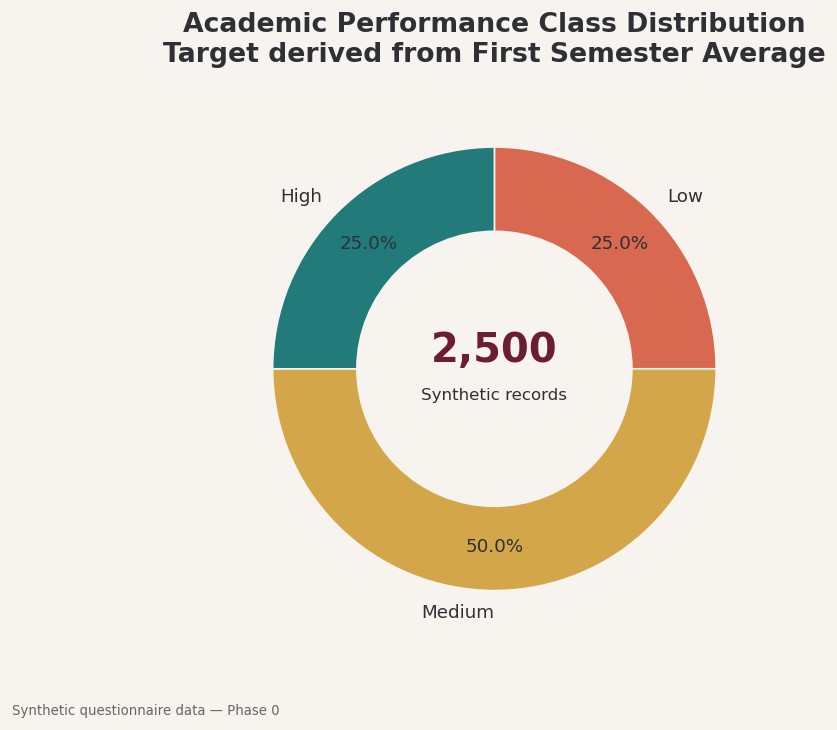

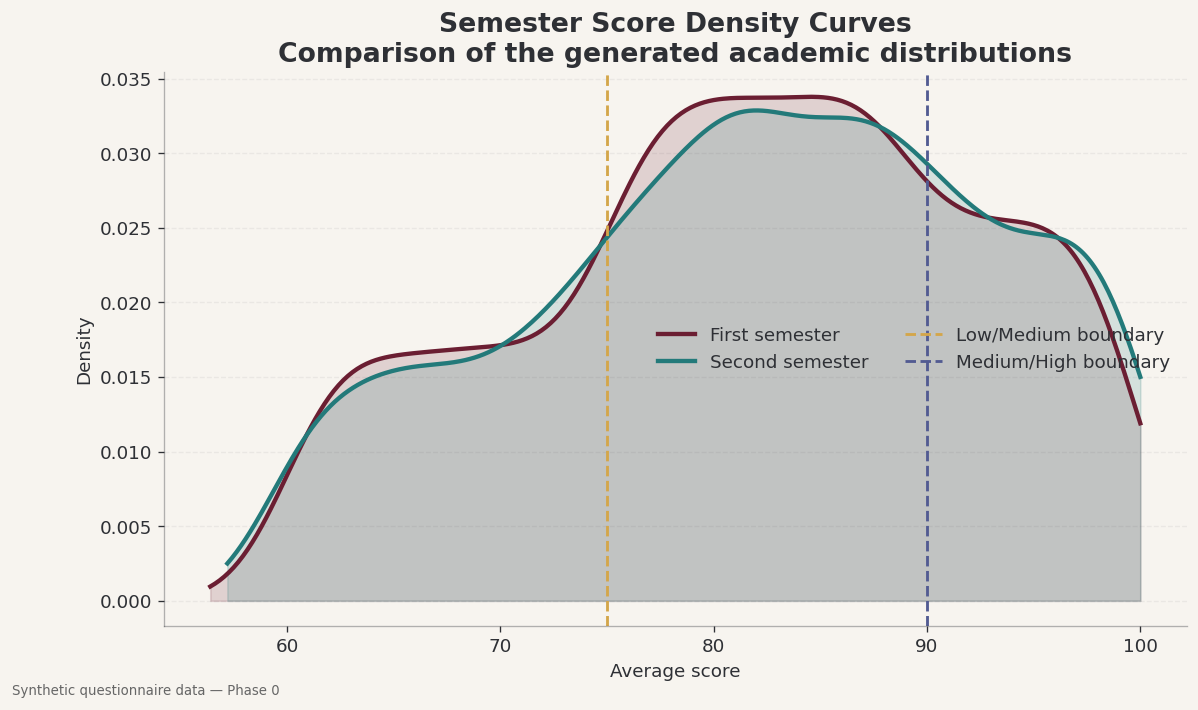

In [19]:

# Cell 0.16.1 — Create Target Donut and Semester Density Visualisations

CELL_FOLDERS = create_cell_folders(
    "00_16",
    "Multiple_Visualization_Synthetic_Dataset",
    "00_16_01",
    "Create_Target_Donut_and_Semester_Density_Visualisations",
)

visualisation_catalogue_rows = []

# Donut chart.
figure, axis = plt.subplots(figsize=(8, 6))
class_labels = target_distribution["academic_performance_class"].tolist()
class_counts = target_distribution["record_count"].tolist()
class_colors = [CLASS_COLORS[label] for label in class_labels]

wedges, texts, autotexts = axis.pie(
    class_counts,
    labels=class_labels,
    colors=class_colors,
    startangle=90,
    counterclock=False,
    autopct="%1.1f%%",
    pctdistance=0.80,
    wedgeprops={"width": 0.38, "edgecolor": THEME["warm_white"]},
)

axis.text(
    0,
    0.08,
    f"{N_RECORDS:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=THEME["maroon"],
)
axis.text(
    0,
    -0.12,
    "Synthetic records",
    ha="center",
    va="center",
    fontsize=10,
    color=THEME["charcoal"],
)
axis.set_title(
    "Academic Performance Class Distribution\n"
    "Target derived from First Semester Average",
    pad=18,
)

add_figure_footer(figure)
path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_01_target_distribution_donut",
)
plt.show()

visualisation_catalogue_rows.append(
    ["Target distribution donut", str(path)]
)

# Density curves.
figure, axis = plt.subplots(figsize=(11, 6))

for column, color, label in [
    ("First Semester Average", THEME["maroon"], "First semester"),
    ("Second Semester Average", THEME["teal"], "Second semester"),
]:
    values = synthetic_data[column].to_numpy(dtype=float)
    x_values = np.linspace(values.min(), values.max(), 400)
    density = gaussian_kde(values)(x_values)
    axis.plot(
        x_values,
        density,
        linewidth=2.6,
        color=color,
        label=label,
    )
    axis.fill_between(
        x_values,
        density,
        alpha=0.16,
        color=color,
    )

axis.axvline(
    75,
    color=THEME["gold"],
    linestyle="--",
    linewidth=1.7,
    label="Low/Medium boundary",
)
axis.axvline(
    90,
    color=THEME["indigo"],
    linestyle="--",
    linewidth=1.7,
    label="Medium/High boundary",
)

axis.set_title(
    "Semester Score Density Curves\n"
    "Comparison of the generated academic distributions"
)
axis.set_xlabel("Average score")
axis.set_ylabel("Density")
style_axis(axis)
axis.legend(frameon=False, ncol=2)
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_01_semester_density_curves",
)
plt.show()

visualisation_catalogue_rows.append(
    ["Semester density curves", str(path)]
)


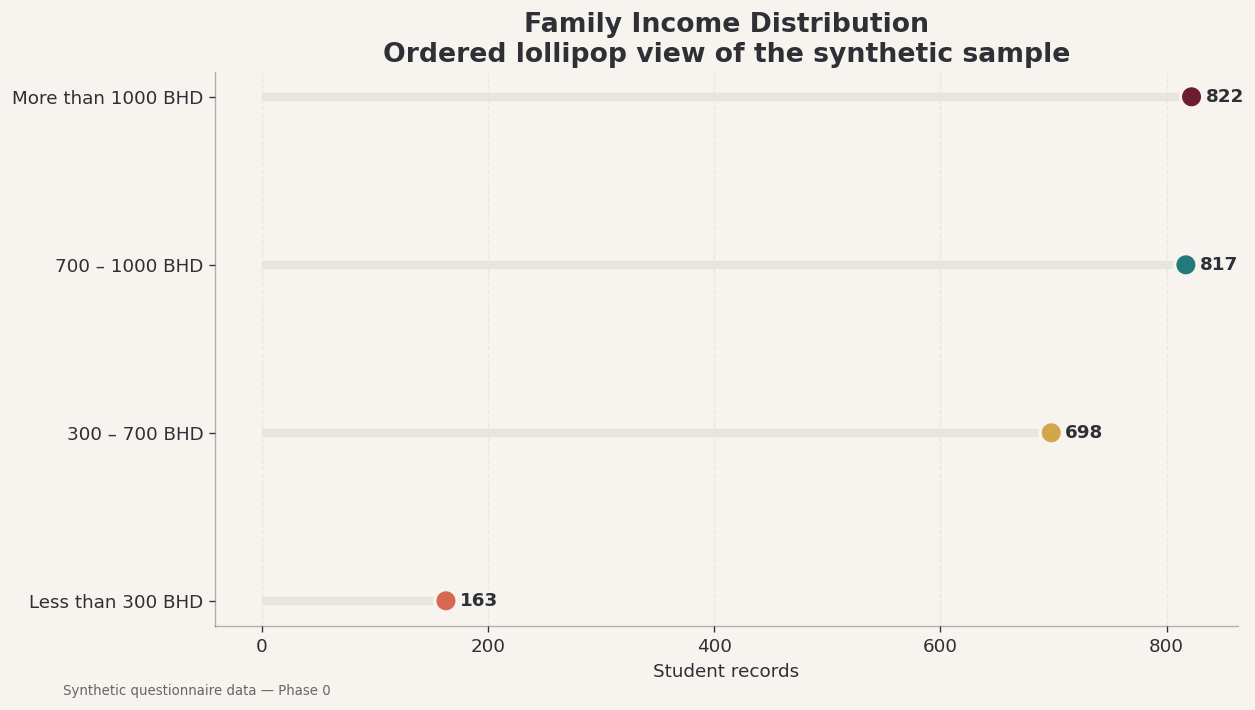

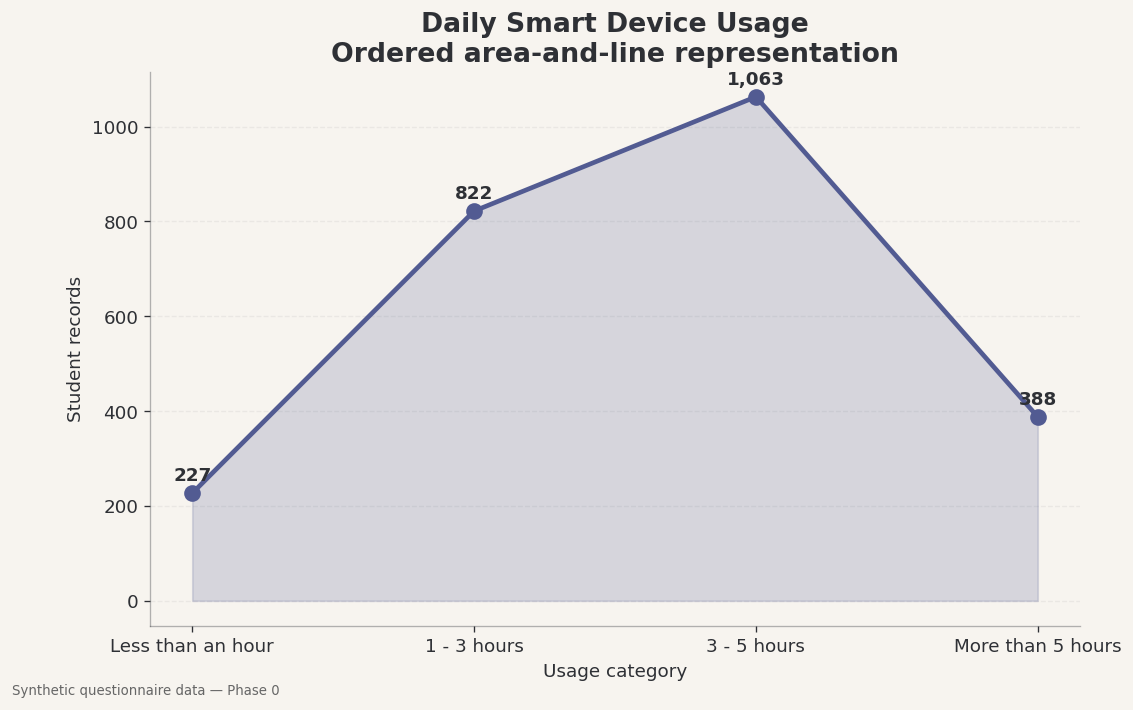

In [20]:

# Cell 0.16.2 — Create Income Lollipop and Device Usage Area Visualisations

CELL_FOLDERS = create_cell_folders(
    "00_16",
    "Multiple_Visualization_Synthetic_Dataset",
    "00_16_02",
    "Create_Income_Lollipop_and_Device_Usage_Area_Visualisations",
)

income_ordered = [
    "Less than 300 BHD",
    "300 – 700 BHD",
    "700 – 1000 BHD",
    "More than 1000 BHD",
]
income_counts = (
    synthetic_data["Family Income"]
    .value_counts()
    .reindex(income_ordered)
)

figure, axis = plt.subplots(figsize=(11, 6))
positions = np.arange(len(income_ordered))
axis.hlines(
    y=positions,
    xmin=0,
    xmax=income_counts.values,
    color=THEME["light_gray"],
    linewidth=5,
)
axis.scatter(
    income_counts.values,
    positions,
    s=180,
    color=[
        THEME["coral"],
        THEME["gold"],
        THEME["teal"],
        THEME["maroon"],
    ],
    edgecolor=THEME["warm_white"],
    linewidth=2,
    zorder=3,
)

for y_position, count in zip(positions, income_counts.values):
    axis.text(
        count + max(income_counts.values) * 0.015,
        y_position,
        f"{count:,}",
        va="center",
        fontweight="bold",
    )

axis.set_yticks(positions)
axis.set_yticklabels(income_ordered)
axis.set_title(
    "Family Income Distribution\n"
    "Ordered lollipop view of the synthetic sample"
)
axis.set_xlabel("Student records")
style_axis(axis, grid_axis="x")
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_02_family_income_lollipop",
)
plt.show()
visualisation_catalogue_rows.append(
    ["Family income lollipop", str(path)]
)

device_ordered = [
    "Less than an hour",
    "1 - 3 hours",
    "3 - 5 hours",
    "More than 5 hours",
]
device_counts = (
    synthetic_data["Daily Smart Device Usage"]
    .value_counts()
    .reindex(device_ordered)
)

figure, axis = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(device_ordered))
axis.plot(
    x_positions,
    device_counts.values,
    marker="o",
    markersize=9,
    linewidth=2.8,
    color=THEME["indigo"],
)
axis.fill_between(
    x_positions,
    device_counts.values,
    alpha=0.20,
    color=THEME["indigo"],
)

for x_position, count in zip(x_positions, device_counts.values):
    axis.text(
        x_position,
        count + max(device_counts.values) * 0.025,
        f"{count:,}",
        ha="center",
        fontweight="bold",
    )

axis.set_xticks(x_positions)
axis.set_xticklabels(device_ordered)
axis.set_title(
    "Daily Smart Device Usage\n"
    "Ordered area-and-line representation"
)
axis.set_xlabel("Usage category")
axis.set_ylabel("Student records")
style_axis(axis)
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_02_device_usage_area_chart",
)
plt.show()
visualisation_catalogue_rows.append(
    ["Device usage area chart", str(path)]
)


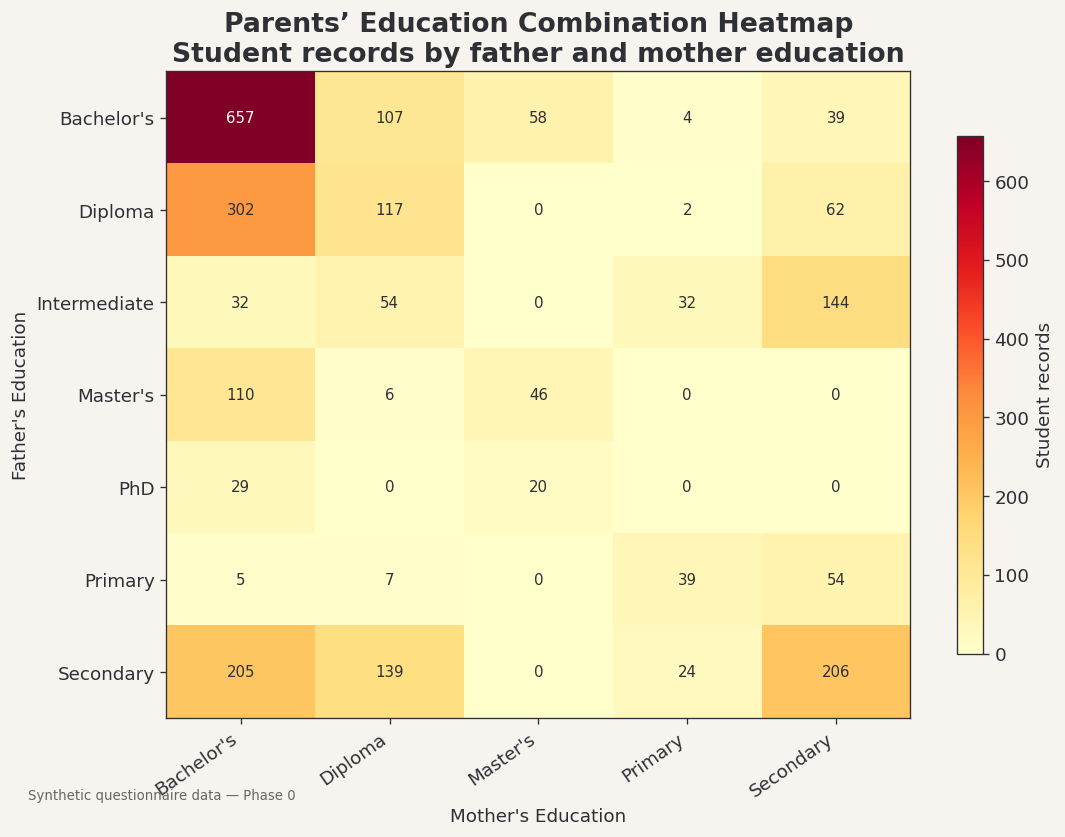

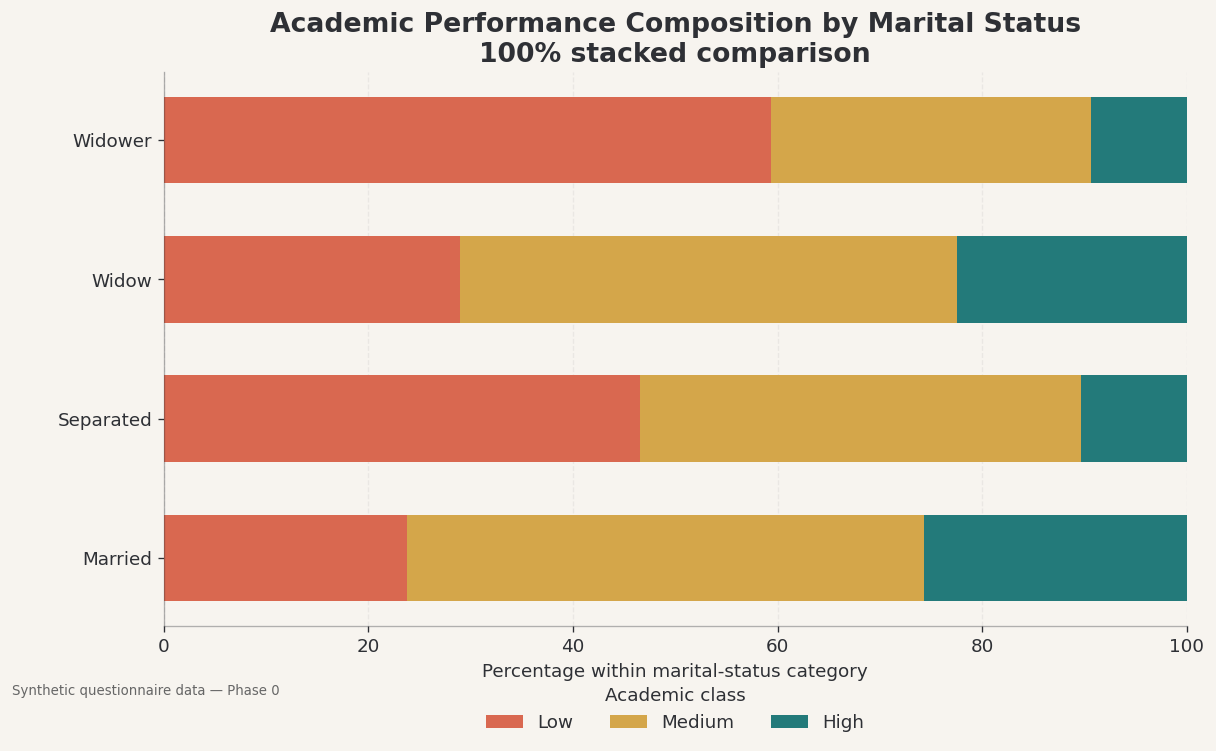

In [21]:

# Cell 0.16.3 — Create Education Heatmap and Family Structure Stacked Chart

CELL_FOLDERS = create_cell_folders(
    "00_16",
    "Multiple_Visualization_Synthetic_Dataset",
    "00_16_03",
    "Create_Education_Heatmap_and_Family_Structure_Stacked_Chart",
)

education_table = pd.crosstab(
    synthetic_data["Father's Education"],
    synthetic_data["Mother's Education"],
)

figure, axis = plt.subplots(figsize=(10, 7))
image = axis.imshow(
    education_table.values,
    cmap="YlOrRd",
    aspect="auto",
)

axis.set_xticks(np.arange(len(education_table.columns)))
axis.set_xticklabels(
    education_table.columns,
    rotation=35,
    ha="right",
)
axis.set_yticks(np.arange(len(education_table.index)))
axis.set_yticklabels(education_table.index)

for row_index in range(education_table.shape[0]):
    for column_index in range(education_table.shape[1]):
        value = education_table.iloc[row_index, column_index]
        axis.text(
            column_index,
            row_index,
            f"{value}",
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if value > education_table.values.max() * 0.55
                else THEME["charcoal"]
            ),
        )

axis.set_title(
    "Parents’ Education Combination Heatmap\n"
    "Student records by father and mother education"
)
axis.set_xlabel("Mother's Education")
axis.set_ylabel("Father's Education")
figure.colorbar(image, ax=axis, shrink=0.8, label="Student records")
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_03_parents_education_heatmap",
)
plt.show()
visualisation_catalogue_rows.append(
    ["Parents education heatmap", str(path)]
)

family_target_table = pd.crosstab(
    synthetic_data["Marital Status"],
    synthetic_target,
    normalize="index",
).reindex(columns=["Low", "Medium", "High"])

figure, axis = plt.subplots(figsize=(11, 6))
left_values = np.zeros(len(family_target_table))

for class_name in ["Low", "Medium", "High"]:
    values = family_target_table[class_name].to_numpy() * 100
    axis.barh(
        family_target_table.index,
        values,
        left=left_values,
        color=CLASS_COLORS[class_name],
        label=class_name,
        height=0.62,
    )
    left_values += values

axis.set_xlim(0, 100)
axis.set_title(
    "Academic Performance Composition by Marital Status\n"
    "100% stacked comparison"
)
axis.set_xlabel("Percentage within marital-status category")
style_axis(axis, grid_axis="x")
axis.legend(
    title="Academic class",
    frameon=False,
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
)
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_03_marital_status_target_stacked",
)
plt.show()
visualisation_catalogue_rows.append(
    ["Marital status target stacked chart", str(path)]
)


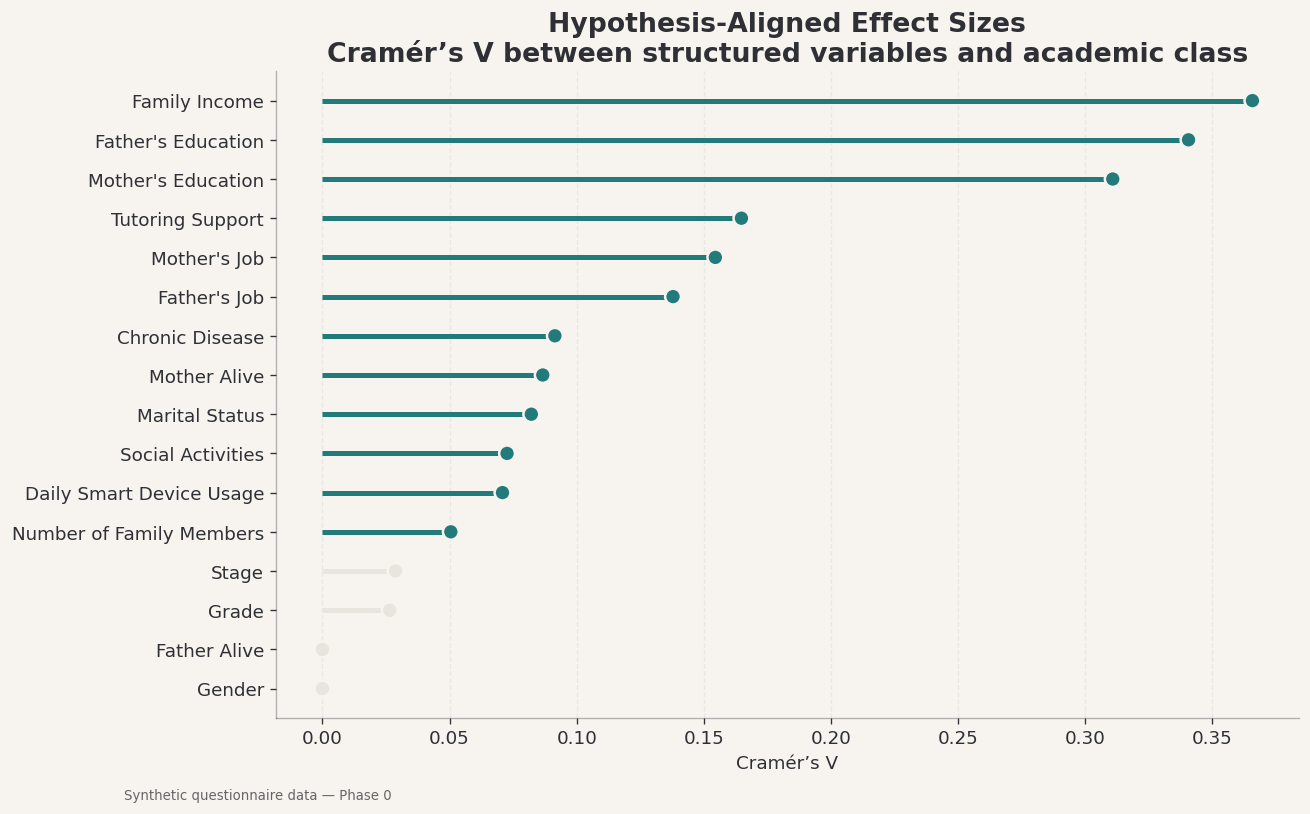

,figure_number,figure_name,relative_path,file_size_kb
0,1,00_16_01_semester_density_curves,Section_00_16_Multiple_Visualization_Synthetic...,281.83
1,2,00_16_01_target_distribution_donut,Section_00_16_Multiple_Visualization_Synthetic...,159.98
2,3,00_16_02_device_usage_area_chart,Section_00_16_Multiple_Visualization_Synthetic...,192.02
3,4,00_16_02_family_income_lollipop,Section_00_16_Multiple_Visualization_Synthetic...,160.22
4,5,00_16_03_marital_status_target_stacked,Section_00_16_Multiple_Visualization_Synthetic...,163.92
5,6,00_16_03_parents_education_heatmap,Section_00_16_Multiple_Visualization_Synthetic...,277.98
6,7,00_16_04_hypothesis_effect_sizes,Section_00_16_Multiple_Visualization_Synthetic...,262.77


In [22]:

# Cell 0.16.4 — Create Hypothesis Effect-Size Plot and Visualisation Catalogue

CELL_FOLDERS = create_cell_folders(
    "00_16",
    "Multiple_Visualization_Synthetic_Dataset",
    "00_16_04",
    "Create_Hypothesis_Effect_Size_Plot_and_Visualisation_Catalogue",
)

effect_plot_data = association_results.sort_values(
    "cramers_v",
    ascending=True,
)

figure, axis = plt.subplots(
    figsize=(11, max(7, len(effect_plot_data) * 0.42))
)

effect_colors = np.where(
    effect_plot_data["significant_at_0_05"],
    THEME["teal"],
    THEME["light_gray"],
)

axis.hlines(
    y=np.arange(len(effect_plot_data)),
    xmin=0,
    xmax=effect_plot_data["cramers_v"],
    color=effect_colors,
    linewidth=3,
)
axis.scatter(
    effect_plot_data["cramers_v"],
    np.arange(len(effect_plot_data)),
    color=effect_colors,
    s=90,
    edgecolor=THEME["warm_white"],
    linewidth=1.5,
    zorder=3,
)

axis.set_yticks(np.arange(len(effect_plot_data)))
axis.set_yticklabels(effect_plot_data["variable"])
axis.set_title(
    "Hypothesis-Aligned Effect Sizes\n"
    "Cramér’s V between structured variables and academic class"
)
axis.set_xlabel("Cramér’s V")
style_axis(axis, grid_axis="x")
add_figure_footer(figure)

path = save_figure(
    figure,
    CELL_FOLDERS,
    "00_16_04_hypothesis_effect_sizes",
)
plt.show()
visualisation_catalogue_rows.append(
    ["Hypothesis effect-size plot", str(path)]
)

all_figure_paths = sorted(PHASE_DIR.rglob("*.png"))
visualisation_catalogue = pd.DataFrame(
    [
        {
            "figure_number": index,
            "figure_name": figure_path.stem,
            "relative_path": str(figure_path.relative_to(PHASE_DIR)),
            "file_size_kb": round(
                figure_path.stat().st_size / 1024,
                2,
            ),
        }
        for index, figure_path in enumerate(all_figure_paths, start=1)
    ]
)

save_dataframe(
    visualisation_catalogue,
    CELL_FOLDERS,
    "00_16_04_visualisation_catalogue",
)
display(visualisation_catalogue)



# Section 0.17 — Export Multiple Files and Phase Handoff

**Description:** Exports the exact questionnaire-compatible synthetic dataset, reports, consolidated workbook, manifest, Phase 1 handoff package, and complete ZIP archive.


In [23]:
# Cell 0.17.1 — Export Final Synthetic Dataset to the Study Data Folder

CELL_FOLDERS = create_cell_folders(
    "00_17",
    "Export_Multiple_Files_and_Phase_Handoff",
    "00_17_01",
    "Export_Final_Synthetic_Dataset_to_the_Study_Data_Folder",
)

# The data folder is the official dataset location used by Phase 1.
FINAL_DATASET_CSV = (
    DATA_DIR / "synthetic_questionnaire_results_2500_records.csv"
)
FINAL_DATASET_XLSX = (
    DATA_DIR / "synthetic_questionnaire_results_2500_records.xlsx"
)

synthetic_data.to_csv(
    FINAL_DATASET_CSV,
    index=False,
    encoding="utf-8-sig",
)
synthetic_data.to_excel(
    FINAL_DATASET_XLSX,
    index=False,
)

# Keep audit copies within the Phase 0 export hierarchy.
AUDIT_DATASET_CSV = (
    CELL_FOLDERS["files"]
    / "synthetic_questionnaire_results_2500_records.csv"
)
AUDIT_DATASET_XLSX = (
    CELL_FOLDERS["files"]
    / "synthetic_questionnaire_results_2500_records.xlsx"
)

shutil.copy2(FINAL_DATASET_CSV, AUDIT_DATASET_CSV)
shutil.copy2(FINAL_DATASET_XLSX, AUDIT_DATASET_XLSX)

dataset_metadata = {
    "dataset_name": FINAL_DATASET_CSV.name,
    "data_source": "SYNTHETIC",
    "records": int(len(synthetic_data)),
    "columns": int(len(synthetic_data.columns)),
    "column_names": synthetic_data.columns.tolist(),
    "optional_source_used": SOURCE_AVAILABLE,
    "source_mode": SOURCE_MODE,
    "official_source_file": (
        str(REFERENCE_DATA_PATH)
        if REFERENCE_DATA_PATH is not None
        else None
    ),
    "schema_basis": (
        "Optional source.csv and approved rules"
        if SOURCE_AVAILABLE
        else "Built-in approved schema and generation rules"
    ),
    "official_study_data_directory": str(DATA_DIR),
    "primary_phase_1_input": str(FINAL_DATASET_CSV),
    "generated_at": datetime.now().isoformat(),
    "random_state": RANDOM_STATE,
    "phase_1_compatible": True,
    "disclaimer": (
        "This dataset is fully synthetic and does not represent real "
        "students, families, schools, or official educational records."
    ),
}

save_json_report(
    dataset_metadata,
    CELL_FOLDERS,
    "00_17_01_dataset_metadata",
)

print("Official Phase 1 CSV:", FINAL_DATASET_CSV)
print("Official Phase 1 XLSX:", FINAL_DATASET_XLSX)
print("Audit copy:", AUDIT_DATASET_CSV)

Official Phase 1 CSV: C:\Users\User\Desktop\All\data\synthetic_questionnaire_results_2500_records.csv
Official Phase 1 XLSX: C:\Users\User\Desktop\All\data\synthetic_questionnaire_results_2500_records.xlsx
Audit copy: C:\Users\User\Desktop\All\outputs\Phase_00_AI_Assisted_Synthetic_Dataset_Generation_and_Validation\Section_00_17_Export_Multiple_Files_and_Phase_Handoff\Cell_00_17_01_Export_Final_Synthetic_Dataset_to_the_Study_Data_Folder\files\synthetic_questionnaire_results_2500_records.csv


In [24]:

# Cell 0.17.2 — Export Consolidated Workbook and File Manifest

CELL_FOLDERS = create_cell_folders(
    "00_17",
    "Export_Multiple_Files_and_Phase_Handoff",
    "00_17_02",
    "Export_Consolidated_Workbook_and_File_Manifest",
)

consolidated_workbook_path = (
    CELL_FOLDERS["files"]
    / "00_17_02_phase_0_consolidated_reports.xlsx"
)

workbook_tables = {
    "Data_Dictionary": data_dictionary,
    "Exact_Schema": exact_schema,
    "Hypothesis_Mapping": hypothesis_mapping,
    "Generation_Config": configuration_table,
    "Structural_Validation": structural_validation,
    "Association_Results": association_results,
    "Hypothesis_Summary": hypothesis_summary,
    "Quality_Checks": quality_checks,
    "Target_Distribution": target_distribution,
    "Visualisation_Index": visualisation_catalogue,
}

with pd.ExcelWriter(
    consolidated_workbook_path,
    engine="openpyxl",
) as writer:
    for sheet_name, table in workbook_tables.items():
        table.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

files_before_manifest = sorted(
    path
    for path in PHASE_DIR.rglob("*")
    if path.is_file()
)

file_manifest = pd.DataFrame(
    [
        {
            "file_number": number,
            "file_name": path.name,
            "extension": path.suffix.lower(),
            "relative_path": str(path.relative_to(PHASE_DIR)),
            "file_size_kb": round(path.stat().st_size / 1024, 2),
        }
        for number, path in enumerate(files_before_manifest, start=1)
    ]
)

save_dataframe(
    file_manifest,
    CELL_FOLDERS,
    "00_17_02_phase_0_file_manifest",
)

display(file_manifest.tail(20))


,file_number,file_name,extension,relative_path,file_size_kb
39,40,00_14_01_hypothesis_alignment_summary.xlsx,.xlsx,Section_00_14_Statistical_Hypothesis_Alignment...,5.26
40,41,00_14_01_variable_association_results.csv,.csv,Section_00_14_Statistical_Hypothesis_Alignment...,1.68
41,42,00_14_01_variable_association_results.xlsx,.xlsx,Section_00_14_Statistical_Hypothesis_Alignment...,6.06
42,43,00_15_01_quality_and_utility_checks.csv,.csv,Section_00_15_Synthetic_Data_Quality_and_Utili...,0.52
43,44,00_15_01_quality_and_utility_checks.xlsx,.xlsx,Section_00_15_Synthetic_Data_Quality_and_Utili...,5.18
44,45,00_15_01_target_distribution.csv,.csv,Section_00_15_Synthetic_Data_Quality_and_Utili...,0.10
45,46,00_15_01_target_distribution.xlsx,.xlsx,Section_00_15_Synthetic_Data_Quality_and_Utili...,4.92
46,47,00_16_01_semester_density_curves.png,.png,Section_00_16_Multiple_Visualization_Synthetic...,281.83
47,48,00_16_01_target_distribution_donut.png,.png,Section_00_16_Multiple_Visualization_Synthetic...,159.98
48,49,00_16_02_device_usage_area_chart.png,.png,Section_00_16_Multiple_Visualization_Synthetic...,192.02


In [25]:

# Cell 0.17.3 — Create Phase 1 Handoff Manifest and ZIP Archive

CELL_FOLDERS = create_cell_folders(
    "00_17",
    "Export_Multiple_Files_and_Phase_Handoff",
    "00_17_03",
    "Create_Phase_1_Handoff_Manifest_and_ZIP_Archive",
)

handoff_manifest = {
    "completed_phase": (
        "Phase 0 — AI-Assisted Synthetic Dataset Generation and Validation"
    ),
    "next_phase": "Phase 1 — Project Setup and Raw Data Understanding",
    "data_source": "SYNTHETIC",
    "primary_input_for_phase_1": str(FINAL_DATASET_CSV),
    "alternative_excel_input": str(FINAL_DATASET_XLSX),
    "records": int(len(synthetic_data)),
    "columns": int(len(synthetic_data.columns)),
    "schema_matches_questionnaire_export": True,
    "optional_source_used": SOURCE_AVAILABLE,
    "source_mode": SOURCE_MODE,
    "data_directory": str(DATA_DIR),
    "structural_validation_passed": bool(
        structural_validation["passed"].all()
    ),
    "quality_validation_passed": bool(quality_checks["passed"].all()),
    "random_state": RANDOM_STATE,
    "generated_at": datetime.now().isoformat(),
    "disclaimer": dataset_metadata["disclaimer"],
}

HANDOFF_MANIFEST_PATH = save_json_report(
    handoff_manifest,
    CELL_FOLDERS,
    "phase_00_handoff_manifest",
)

summary_text = f"""
PHASE 0 COMPLETION SUMMARY
{'=' * 72}

Project:
{PROJECT_TITLE}

Student:
{STUDENT_NAME} | ID: {STUDENT_ID}

Generated dataset:
{FINAL_DATASET_CSV.name}

Records:
{len(synthetic_data):,}

Columns:
{len(synthetic_data.columns)}

Schema basis:
{"source.csv in data_source" if SOURCE_AVAILABLE else "Built-in approved schema and rules"}

Validation:
- Structural validation passed: {structural_validation['passed'].all()}
- Quality validation passed: {quality_checks['passed'].all()}
- Exact questionnaire schema: True
- Phase 1 compatible: True

Important:
The dataset is fully synthetic. It can be processed by Phase 1 like an
independent questionnaire export, but its origin must remain disclosed in
the methodology and metadata.
""".strip()

summary_path = CELL_FOLDERS["reports"] / "00_17_03_phase_0_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

zip_path = (
    CELL_FOLDERS["files"]
    / "00_17_03_phase_0_complete_export.zip"
)

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zip_file:
    for file_path in sorted(PHASE_DIR.rglob("*")):
        if not file_path.is_file() or file_path == zip_path:
            continue
        zip_file.write(
            file_path,
            file_path.relative_to(PHASE_DIR),
        )

print(summary_text)
print("\nPhase 1 handoff manifest:", HANDOFF_MANIFEST_PATH)
print("Complete ZIP archive:", zip_path)


PHASE 0 COMPLETION SUMMARY

Project:
Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

Student:
Jaafar Ahmed | ID: 202508989

Generated dataset:
synthetic_questionnaire_results_2500_records.csv

Records:
2,500

Columns:
25

Schema basis:
source.csv in data_source

Validation:
- Structural validation passed: True
- Quality validation passed: True
- Exact questionnaire schema: True
- Phase 1 compatible: True

Important:
The dataset is fully synthetic. It can be processed by Phase 1 like an
independent questionnaire export, but its origin must remain disclosed in
the methodology and metadata.

Phase 1 handoff manifest: C:\Users\User\Desktop\All\outputs\Phase_00_AI_Assisted_Synthetic_Dataset_Generation_and_Validation\Section_00_17_Export_Multiple_Files_and_Phase_Handoff\Cell_00_17_03_Create_Phase_1_Handoff_Manifest_and_ZIP_Archive\reports\phase_00_handoff_manifest.json
Complete ZIP archive: C:\Users\User\Desk

# Phase 0 Completed

The final output is an exact 25-column synthetic questionnaire dataset.

- `data_source` is an optional reference-input folder.
- Any supported source filename is accepted and standardised as `source.csv`.
- If `data_source` is empty, generation continues directly using the approved built-in rules.
- The final synthetic CSV and Excel files are saved in the official `data` folder.
- Phase 1 can use the generated dataset as:

```python
DATA_SOURCE = "SYNTHETIC"
```

Phase 1 should read `phase_00_handoff_manifest.json` or load the generated CSV directly from `data`.